# BUSI Breast Ultrasound Tumour Segmentation — nnU-Net (v2)

**Task**: Training Task 6 — train three segmentation models (U-Net, nnU-Net, DeepLabV3+)
on BUSI and compare them fairly. This notebook runs **nnU-Net v2** (Isensee et al., 2021),
a self-configuring framework: it inspects the dataset, picks the network topology, patch
size and training pipeline automatically, and trains a U-Net with that recipe.

Workflow: (1) convert BUSI to the nnU-Net raw-data layout + `dataset.json`,
(2) `nnUNetv2_plan_and_preprocess`, (3) `nnUNetv2_train` with a small custom trainer,
(4) `nnUNetv2_predict`, (5) evaluate with exactly the same metric code as the other two
notebooks.

### What is unified with U-Net / DeepLabV3+

| Setting | How it is matched |
|---|---|
| Train / test split | the same `train.xlsx` (517) / `test.xlsx` (130); nnU-Net trains on fold **`all`** (all 517 images, no internal 5-fold CV) |
| Input size | images are resized to 256×256 before conversion; nnU-Net's plan gives a 256×256 patch, i.e. it sees the whole image |
| Preprocessing / normalisation | grayscale, same bilinear resize, per-image z-score (nnU-Net's default `ZScoreNormalization` for a non-CT channel) |
| Random seed | 42, set inside the custom trainer |
| Batch size | 16, written into the plans file after planning |
| Epochs | 100, and **33 iterations per epoch** (= ceil(517/16), same as the other models' DataLoader) instead of nnU-Net's 250 |
| Model selection | final checkpoint (`checkpoint_final.pth`), no test-set peeking |
| Test-time protocol | test-time mirroring disabled (`--disable_tta`) because the other models use no TTA; the class-1 probability is upsampled bilinearly to the original size and thresholded at 0.5 |
| Metrics | identical code and empty-prediction rule |

### What is deliberately left at nnU-Net's defaults, and why

nnU-Net *is* its recipe: if we replaced every part of it with the U-Net notebook's
settings, we would just be training a second plain U-Net and the comparison would no
longer tell us anything about nnU-Net. So these stay as nnU-Net designed them:

- **Optimizer / learning rate**: SGD with Nesterov momentum 0.99, initial LR 1e-2 and
  polynomial decay. nnU-Net's training stability is tuned to this combination; Adam at
  1e-4 is not what the method prescribes.
- **Deep supervision**: auxiliary losses at several decoder resolutions — a core part of
  the nnU-Net architecture/training.
- **Data augmentation**: nnU-Net's own pipeline (rotation, scaling, Gaussian noise/blur,
  brightness, contrast, simulated low resolution, gamma, mirroring). It is integral to
  the method and cannot be swapped for ours without rewriting its dataloader.
- **Loss**: Dice + cross-entropy on 2-class softmax (the multi-class form of our
  Dice + BCE).
- **Network topology**: chosen automatically by the planner (printed below).
- **No post-processing**: nnU-Net's optional "keep largest component" step is selected
  by cross-validation, which fold `all` does not provide, so it is not applied.

Because nnU-Net's data loading runs in background worker processes, its seeding is
reproducible only approximately (the same holds for any multi-worker augmentation).

**Outputs (all in this folder)**: weights `nnUNet_results/Dataset501_BUSI/nnUNetTrainer_BUSIfair__nnUNetPlans__2d/fold_all/checkpoint_final.pth`,
binary masks `predictions/*.png`, `per_image_metrics.csv`,
`outputs/nnunet_test_metrics.json`, training curve `outputs/nnunet_progress.png`.

## 1. Configuration

All paths and hyperparameters live in this one cell. The *shared hyperparameters* block is
copied verbatim from the U-Net / DeepLabV3+ notebooks; the comments in the intro table say
which of them nnU-Net honours and which it overrides by design (optimizer, LR, loss
form, augmentation). The nnU-Net-specific block also sets nnU-Net's environment variables.

In [1]:
import os

# ===== Paths =====
DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
LABELS_DIR = os.path.join(DATASET_DIR, "labels")
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
IMAGE_COL = "Image"   # column holding the filename in both xlsx files

MODEL_NAME = "nnunet"
MODEL_LABEL = "nnU-Net"
MODEL_COLOR = "#eb6834"   # this model's colour in every figure (same in Task 7)
OUTPUT_DIR = "outputs"         # weights, loss curve, metric summary
PRED_DIR = "predictions"       # predicted binary masks, PNG at original resolution (0/255)
METRICS_CSV = "per_image_metrics.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# ===== Shared hyperparameters — IDENTICAL across U-Net / nnU-Net / DeepLabV3+ =====
IMG_SIZE = 256            # every model sees 256x256 inputs
RANDOM_SEED = 42
BATCH_SIZE = 16
NUM_EPOCHS = 100          # one epoch = ceil(517 / 16) = 33 iterations for all three models
OPTIMIZER = "Adam"        # nnU-Net keeps its own SGD — see the nnU-Net notebook
LEARNING_RATE = 1e-4
LOSS = "Dice + BCE"       # nnU-Net uses its equivalent Dice + CE (2-class softmax)
THRESHOLD = 0.5           # probability -> binary mask

# Preprocessing: grayscale (1 channel) -> resize to IMG_SIZE (bilinear; masks nearest)
# -> per-image z-score normalisation (x - mean) / std, the same rule nnU-Net applies.

# Data augmentation (training set only), applied jointly to image and mask
AUG_HFLIP_P = 0.5             # horizontal flip probability
AUG_ROTATE_DEG = 15           # rotation uniformly sampled in [-15, 15] degrees
AUG_SCALE = (0.9, 1.1)        # isotropic zoom factor
AUG_BRIGHTNESS = 0.1          # additive shift in z-score units, uniform in [-0.1, 0.1]
AUG_CONTRAST = (0.9, 1.1)     # multiplicative contrast factor

# HD95 rule for an EMPTY prediction (no foreground pixel predicted):
# HD95 = diagonal of the ORIGINAL image, sqrt(H^2 + W^2) pixels (the worst possible
# distance), Dice = IoU = 0. Ground-truth masks are never empty in BUSI (checked below).

# ===== nnU-Net specific settings =====
DATASET_ID = 501
DATASET_NAME = f"Dataset{DATASET_ID:03d}_BUSI"
CONFIGURATION = "2d"
FOLD = "all"                         # train on all 517 training images (no internal CV)
TRAINER = "nnUNetTrainer_BUSIfair"   # custom trainer: epochs / iterations / seed (section 8)
ITERS_PER_EPOCH = -(-517 // BATCH_SIZE)   # ceil(517 / 16) = 33, same as the DataLoader elsewhere
NUM_PROC = 8                          # CPU processes for preprocessing / augmentation

# nnU-Net finds its data through three environment variables; all three point inside
# this folder so the raw data, preprocessed data and trained weights stay together.
NNUNET_HOME = os.path.abspath(".")
os.environ["nnUNet_raw"] = os.path.join(NNUNET_HOME, "nnUNet_raw")
os.environ["nnUNet_preprocessed"] = os.path.join(NNUNET_HOME, "nnUNet_preprocessed")
os.environ["nnUNet_results"] = os.path.join(NNUNET_HOME, "nnUNet_results")
os.environ["nnUNet_n_proc_DA"] = str(NUM_PROC)
os.environ["nnUNet_compile"] = "f"   # torch.compile off: not needed and fragile on aarch64
for k in ["nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    os.makedirs(os.environ[k], exist_ok=True)
    print(f"{k} = {os.environ[k]}")

nnUNet_raw = /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnUNet_raw


nnUNet_preprocessed = /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnUNet_preprocessed
nnUNet_results = /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnUNet_results


## 2. Imports, reproducibility and a helper to run nnU-Net commands

nnU-Net is driven through its command-line tools; `run()` executes one and streams its
output into the notebook so the full training log is saved in the executed `.ipynb`.

In [2]:
import json
import random
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from medpy.metric import binary as medpy_binary

import re
import shutil
import subprocess
import sys

import torch
import torch.nn.functional as F
# Import after the environment variables are set (nnunetv2 reads them at import time)
from nnunetv2.dataset_conversion.generate_dataset_json import generate_dataset_json
import nnunetv2

# Fix the seeds of this notebook process (the trainer seeds itself, see section 8)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print("torch", torch.__version__, "| nnunetv2 at", os.path.dirname(nnunetv2.__file__))
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

# nnU-Net command-line tools live next to the kernel's python executable
BIN = os.path.dirname(sys.executable)


def run(cmd):
    """Run an nnU-Net CLI command, stream its output into the notebook, fail loudly."""
    print("$", " ".join(cmd), flush=True)
    proc = subprocess.Popen([os.path.join(BIN, cmd[0])] + cmd[1:], stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, env=os.environ.copy())
    for line in proc.stdout:
        # drop intermediate tqdm progress-bar refreshes, keep the final 100% line
        if re.search(r"\|\s*\d+/\d+ \[", line) and "100%" not in line:
            continue
        print(line, end="")
    if proc.wait() != 0:
        raise RuntimeError(f"command failed with exit code {proc.returncode}")

torch 2.14.0+cu130 | nnunetv2 at /mnt/cv_data/users/hahaxixi/envs/ml/lib/python3.11/site-packages/nnunetv2
GPU: NVIDIA GB10


## 3. Load the fixed train/test split

The split comes from `train.xlsx` (517 images) and `test.xlsx` (130 images) — we never
re-split randomly. We also check that the two lists do not overlap and that every listed
file exists in `images/`.

In [3]:
train_df = pd.read_excel(TRAIN_XLSX)
test_df = pd.read_excel(TEST_XLSX)
train_names = train_df[IMAGE_COL].tolist()
test_names = test_df[IMAGE_COL].tolist()   # this order is used for every per-image output

assert not set(train_names) & set(test_names), "train and test overlap"
for n in train_names + test_names:
    assert os.path.exists(os.path.join(IMAGES_DIR, n)), f"missing image {n}"
print(f"train: {len(train_names)} images, test: {len(test_names)} images")

train: 517 images, test: 130 images


## 4. Image ↔ mask correspondence (and merging multiple masks)

In `~/datasets/BUSI/labels/` each mask has **exactly the same filename** as its image
(`images/benign (1).png` ↔ `labels/benign (1).png`). The original BUSI release stores
extra lesions as separate files (`benign (4)_mask_1.png`); `mask_files_for` also picks
those up and `load_mask` merges them with a pixel-wise OR into one binary mask, so the
code stays correct even on a copy of BUSI that was not pre-merged.

Mask PNGs are palette images whose pixel values are 0 (background) / 1 (tumour); we
binarise with `> 0` so 0/255 masks would work too.

In [4]:
LABEL_FILES = set(os.listdir(LABELS_DIR))


def mask_files_for(name):
    """All mask files belonging to image `name`: the same filename, plus `<stem>_mask*`."""
    stem, _ = os.path.splitext(name)
    files = [name] if name in LABEL_FILES else []
    # "benign (1)_mask..." cannot collide with "benign (10)" because of the "_mask" suffix
    files += sorted(f for f in LABEL_FILES if f.startswith(stem + "_mask"))
    return files


def load_image(name):
    """Ultrasound is grayscale even though the PNG is RGB -> uint8 H x W."""
    return np.array(Image.open(os.path.join(IMAGES_DIR, name)).convert("L"))


def load_mask(name):
    """Binary uint8 H x W tumour mask, all mask files of the image merged with OR."""
    files = mask_files_for(name)
    assert files, f"no mask found for {name}"
    merged = None
    for f in files:
        m = np.array(Image.open(os.path.join(LABELS_DIR, f)))  # palette index = label
        if m.ndim == 3:                                         # RGB mask -> any channel
            m = m.max(axis=2)
        merged = (m > 0) if merged is None else (merged | (m > 0))
    return merged.astype(np.uint8)


# Verify the correspondence on the whole dataset
n_multi, n_empty = 0, 0
for n in train_names + test_names:
    files = mask_files_for(n)
    n_multi += len(files) > 1
    m = load_mask(n)
    assert m.shape == load_image(n).shape, f"size mismatch for {n}"
    n_empty += m.sum() == 0
print(f"images with >1 mask file (merged): {n_multi}")
print(f"empty ground-truth masks: {n_empty}")
assert n_empty == 0  # the HD95 rule below relies on every GT mask containing a tumour

images with >1 mask file (merged): 0
empty ground-truth masks: 0


## 5. Convert BUSI to the nnU-Net raw-data format

nnU-Net expects this layout under `$nnUNet_raw`:

```
nnUNet_raw/Dataset501_BUSI/
├── dataset.json
├── imagesTr/BUSI_001_0000.png   # <case id>_<channel 0000>.png  (training images)
├── labelsTr/BUSI_001.png        # <case id>.png, values 0 = background, 1 = tumour
└── imagesTs/BUSI_518_0000.png   # test images (never used for training)
```

Case ids replace the original filenames, which contain spaces and brackets; the mapping
is saved to `case_mapping.csv`. Every image goes through **exactly the same steps as in
the other notebooks**: grayscale, bilinear resize to 256×256 (mask: nearest-neighbour,
with multiple masks merged). We store the resized image as uint8 PNG and let nnU-Net
apply the per-image z-score itself.

`dataset.json` declares one input channel (`"0": "ultrasound"` — any name other than
`CT` makes nnU-Net use per-image z-score normalisation), the labels, the number of
training cases and the file ending.

In [5]:
raw_dir = os.path.join(os.environ["nnUNet_raw"], DATASET_NAME)
if os.path.isdir(raw_dir):
    shutil.rmtree(raw_dir)          # rebuild from scratch on every run
for sub in ["imagesTr", "labelsTr", "imagesTs"]:
    os.makedirs(os.path.join(raw_dir, sub))


def resize_image_u8(img):
    """Same bilinear resize as preprocess_image() in the other notebooks, kept as uint8."""
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)


def resize_mask(m):
    return cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)


mapping = []
for i, name in enumerate(train_names + test_names, start=1):
    case = f"BUSI_{i:03d}"
    split = "train" if i <= len(train_names) else "test"
    img_sub = "imagesTr" if split == "train" else "imagesTs"
    Image.fromarray(resize_image_u8(load_image(name))).save(os.path.join(raw_dir, img_sub, f"{case}_0000.png"))
    if split == "train":            # labels only for training cases
        Image.fromarray(resize_mask(load_mask(name))).save(os.path.join(raw_dir, "labelsTr", f"{case}.png"))
    mapping.append({"case_id": case, "image_name": name, "split": split})
mapping_df = pd.DataFrame(mapping)
mapping_df.to_csv("case_mapping.csv", index=False)

generate_dataset_json(
    raw_dir,
    channel_names={0: "ultrasound"},
    labels={"background": 0, "tumor": 1},
    num_training_cases=len(train_names),
    file_ending=".png",
    dataset_name=DATASET_NAME,
    description="BUSI benign+malignant, resized to 256x256, fixed train.xlsx/test.xlsx split",
    reference="Al-Dhabyani et al., Dataset of breast ultrasound images, Data in Brief 2020",
    license="see the original BUSI dataset release",
)
print(open(os.path.join(raw_dir, "dataset.json")).read())
print({sub: len(os.listdir(os.path.join(raw_dir, sub))) for sub in ["imagesTr", "labelsTr", "imagesTs"]})

{
    "channel_names": {
        "0": "ultrasound"
    },
    "labels": {
        "background": 0,
        "tumor": 1
    },
    "numTraining": 517,
    "file_ending": ".png",
    "licence": "see the original BUSI dataset release",
    "converted_by": "Please enter your name, especially when sharing datasets with others in a common infrastructure!",
    "name": "Dataset501_BUSI",
    "reference": "Al-Dhabyani et al., Dataset of breast ultrasound images, Data in Brief 2020",
    "description": "BUSI benign+malignant, resized to 256x256, fixed train.xlsx/test.xlsx split"
}
{'imagesTr': 517, 'labelsTr': 517, 'imagesTs': 130}


## 6. Fingerprint, planning and preprocessing

`nnUNetv2_plan_and_preprocess` extracts a dataset fingerprint (image sizes, spacing,
intensities), derives the 2D configuration (network depth, patch size, batch size,
normalisation) and writes preprocessed arrays to `$nnUNet_preprocessed`.
`--verify_dataset_integrity` checks that images and labels match.

In [6]:
run(["nnUNetv2_plan_and_preprocess", "-d", str(DATASET_ID), "-c", CONFIGURATION,
     "--verify_dataset_integrity", "-np", str(NUM_PROC)])

$ nnUNetv2_plan_and_preprocess -d 501 -c 2d --verify_dataset_integrity -np 8


Fingerprint extraction...
Dataset501_BUSI
Using <class 'nnunetv2.imageio.natural_image_reader_writer.NaturalImage2DIO'> as reader/writer



####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.natural_image_reader_writer.NaturalImage2DIO'> as reader/writer



Extracting dataset fingerprint: 100%|██████████| 517/517 [00:02<00:00, 233.28it/s]


Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################



2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 26, 'patch_size': (np.int64(256), np.int64(256)), 'median_image_size_in_voxels': array([256., 256.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resampling_fn_probabilities_kwargs': {'is_seg': False, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'architecture': {'network_class_name': 'dynamic_network_architectures.architectures.unet.PlainConvUNet', 'arch_kwargs': {'n_stages': 7, 'features_per_stage': (32, 64, 128, 256, 512, 512, 512

Preprocessing cases: 100%|█████████▉| 516/517 [13:38<00:00,  1.04it/s]


Preprocessing cases: 100%|██████████| 517/517 [13:38<00:00,  1.58s/it]


## 7. Inspect the plan and set the batch size to 16

nnU-Net picks the batch size from a GPU-memory budget, usually larger than 16 for
256×256 2D images. The documented way to change it is to edit the configuration in
`nnUNetPlans.json`; we set it to `BATCH_SIZE` so all three models see 16 images per step.
We also assert that the patch is the full 256×256 image.

In [7]:
plans_path = os.path.join(os.environ["nnUNet_preprocessed"], DATASET_NAME, "nnUNetPlans.json")
with open(plans_path) as f:
    plans = json.load(f)
cfg = plans["configurations"][CONFIGURATION]
print("auto-configured batch size :", cfg["batch_size"])
print("patch size                 :", cfg["patch_size"])
print("normalisation              :", cfg["normalization_schemes"])
arch = cfg["architecture"]["arch_kwargs"]
print("network                    :", cfg["architecture"]["network_class_name"].split(".")[-1])
print("stages / features per stage:", arch["n_stages"], arch["features_per_stage"])

assert list(cfg["patch_size"]) == [IMG_SIZE, IMG_SIZE], "patch should cover the whole 256x256 image"
cfg["batch_size"] = BATCH_SIZE
with open(plans_path, "w") as f:
    json.dump(plans, f, indent=2)
print(f"-> batch size set to {BATCH_SIZE} in {plans_path}")

auto-configured batch size : 26
patch size                 : [256, 256]
normalisation              : ['ZScoreNormalization']
network                    : PlainConvUNet
stages / features per stage: 7 [32, 64, 128, 256, 512, 512, 512]
-> batch size set to 16 in /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnUNet_preprocessed/Dataset501_BUSI/nnUNetPlans.json


## 8. Custom trainer: 100 epochs × 33 iterations, seed 42

nnU-Net's default is 1000 epochs of 250 iterations. A minimal subclass of `nnUNetTrainer`
changes only the training length and seeds the RNGs; everything else (SGD 1e-2 + poly LR,
deep supervision, augmentation, Dice + CE loss) is inherited unchanged. With fold `all`
the "validation" set is the training set, so the per-epoch pseudo-validation is reduced to
10 iterations to save time — it does not influence training or checkpoint selection.

nnU-Net looks trainers up by class name inside its own package, so the file is written to
this folder (for the record) and copied into `nnunetv2/training/nnUNetTrainer/variants/`.

In [8]:
trainer_src = f"""import random

import numpy as np
import torch

from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer


class {TRAINER}(nnUNetTrainer):
    \"\"\"nnU-Net defaults, but training length and seed matched to the BUSI comparison.\"\"\"

    def __init__(self, plans, configuration, fold, dataset_json, device=torch.device("cuda")):
        super().__init__(plans, configuration, fold, dataset_json, device)
        self.num_epochs = {NUM_EPOCHS}
        self.num_iterations_per_epoch = {ITERS_PER_EPOCH}
        self.num_val_iterations_per_epoch = 10
        random.seed({RANDOM_SEED})
        np.random.seed({RANDOM_SEED})
        torch.manual_seed({RANDOM_SEED})
        torch.cuda.manual_seed_all({RANDOM_SEED})
"""
local_trainer = f"{TRAINER}.py"
with open(local_trainer, "w") as f:
    f.write(trainer_src)
variants_dir = os.path.join(os.path.dirname(nnunetv2.__file__), "training", "nnUNetTrainer", "variants")
shutil.copy(local_trainer, os.path.join(variants_dir, local_trainer))
print(trainer_src)
print("installed ->", os.path.join(variants_dir, local_trainer))

import random

import numpy as np
import torch

from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer


class nnUNetTrainer_BUSIfair(nnUNetTrainer):
    """nnU-Net defaults, but training length and seed matched to the BUSI comparison."""

    def __init__(self, plans, configuration, fold, dataset_json, device=torch.device("cuda")):
        super().__init__(plans, configuration, fold, dataset_json, device)
        self.num_epochs = 100
        self.num_iterations_per_epoch = 33
        self.num_val_iterations_per_epoch = 10
        random.seed(42)
        np.random.seed(42)
        torch.manual_seed(42)
        torch.cuda.manual_seed_all(42)

installed -> /mnt/cv_data/users/hahaxixi/envs/ml/lib/python3.11/site-packages/nnunetv2/training/nnUNetTrainer/variants/nnUNetTrainer_BUSIfair.py


## 9. Train

`nnUNetv2_train <dataset> <configuration> <fold> -tr <trainer>`. The log of every epoch
(train loss, pseudo-validation loss and Dice, learning rate, epoch time) is streamed below.

In [9]:
t0 = time.time()
run(["nnUNetv2_train", str(DATASET_ID), CONFIGURATION, FOLD, "-tr", TRAINER])
print(f"training wall time: {time.time() - t0:.0f}s")

model_dir = os.path.join(os.environ["nnUNet_results"], DATASET_NAME, f"{TRAINER}__nnUNetPlans__{CONFIGURATION}")
WEIGHTS_PATH = os.path.join(model_dir, f"fold_{FOLD}", "checkpoint_final.pth")
assert os.path.exists(WEIGHTS_PATH)
print("weights:", WEIGHTS_PATH)

$ nnUNetv2_train 501 2d all -tr nnUNetTrainer_BUSIfair


/mnt/cv_data/users/hahaxixi/envs/ml/lib/python3.11/site-packages/torch/jit/_script.py:1643: FutureWarning: `torch.jit.interface` is deprecated. Please use `torch.compile` instead.
  warnings.warn(



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-10-05 12:20:51.792498: do_dummy_2d_data_aug: False


using pin_memory on device 0


using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 16, 'patch_size': [256, 256], 'median_image_size_in_voxels': [256.0, 256.0], 'spacing': [1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resampling_fn_probabilities_kwargs': {'is_seg': False, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'architecture': {'network_class_name': 'dynamic_network_architectures.architectures.unet.PlainConvUNet', 'arch_kwargs': {'n_stages': 7, 'feat

...

2026-10-05 12:37:02.989559: BUSI_382, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:03.119473: predicting BUSI_383
2026-10-05 12:37:03.206986: BUSI_383, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:03.360015: predicting BUSI_384
2026-10-05 12:37:03.448347: BUSI_384, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:03.602985: predicting BUSI_385
2026-10-05 12:37:03.686798: BUSI_385, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:03.835924: predicting BUSI_386
2026-10-05 12:37:03.923697: BUSI_386, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:04.078103: predicting BUSI_387
2026-10-05 12:37:04.165751: BUSI_387, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:04.317684: predicting BUSI_388
2026-10-05 12:37:04.399689: BUSI_388, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:04.543644: predicting BUSI_389
2026-10-05 12:37:04.624369: BUSI_389, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37

2026-10-05 12:37:19.510631: BUSI_446, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:19.634906: predicting BUSI_447
2026-10-05 12:37:19.744635: BUSI_447, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:19.917958: predicting BUSI_448
2026-10-05 12:37:19.994101: BUSI_448, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:20.129468: predicting BUSI_449
2026-10-05 12:37:20.219040: BUSI_449, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:20.361798: predicting BUSI_450
2026-10-05 12:37:20.438900: BUSI_450, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:20.598135: predicting BUSI_451
2026-10-05 12:37:20.719671: BUSI_451, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:20.859637: predicting BUSI_452
2026-10-05 12:37:20.935758: BUSI_452, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:21.127874: predicting BUSI_453
2026-10-05 12:37:21.413463: BUSI_453, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37

2026-10-05 12:37:36.709215: predicting BUSI_510
2026-10-05 12:37:36.794492: BUSI_510, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:36.977861: predicting BUSI_511
2026-10-05 12:37:37.068546: BUSI_511, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:37.207807: predicting BUSI_512
2026-10-05 12:37:37.292301: BUSI_512, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:37.466118: predicting BUSI_513
2026-10-05 12:37:37.551816: BUSI_513, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:37.720921: predicting BUSI_514
2026-10-05 12:37:37.810182: BUSI_514, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:38.013992: predicting BUSI_515
2026-10-05 12:37:38.100022: BUSI_515, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:38.276273: predicting BUSI_516
2026-10-05 12:37:38.362653: BUSI_516, shape torch.Size([1, 1, 256, 256]), rank 0
2026-10-05 12:37:38.491627: predicting BUSI_517
2026-10-05 12:37:38.614501: BUSI_517, shape torch

2026-10-05 12:37:44.892061: Validation complete
2026-10-05 12:37:44.965238: Mean Validation Dice:  0.8732361105762768


training wall time: 1028s
weights: /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnUNet_results/Dataset501_BUSI/nnUNetTrainer_BUSIfair__nnUNetPlans__2d/fold_all/checkpoint_final.pth


## 10. Training curve

nnU-Net draws its own progress plot (losses, pseudo-Dice, epoch time, learning rate).
Remember the "validation" here is the training set (fold `all`), so it is not a
generalisation estimate. We copy it to `outputs/`.

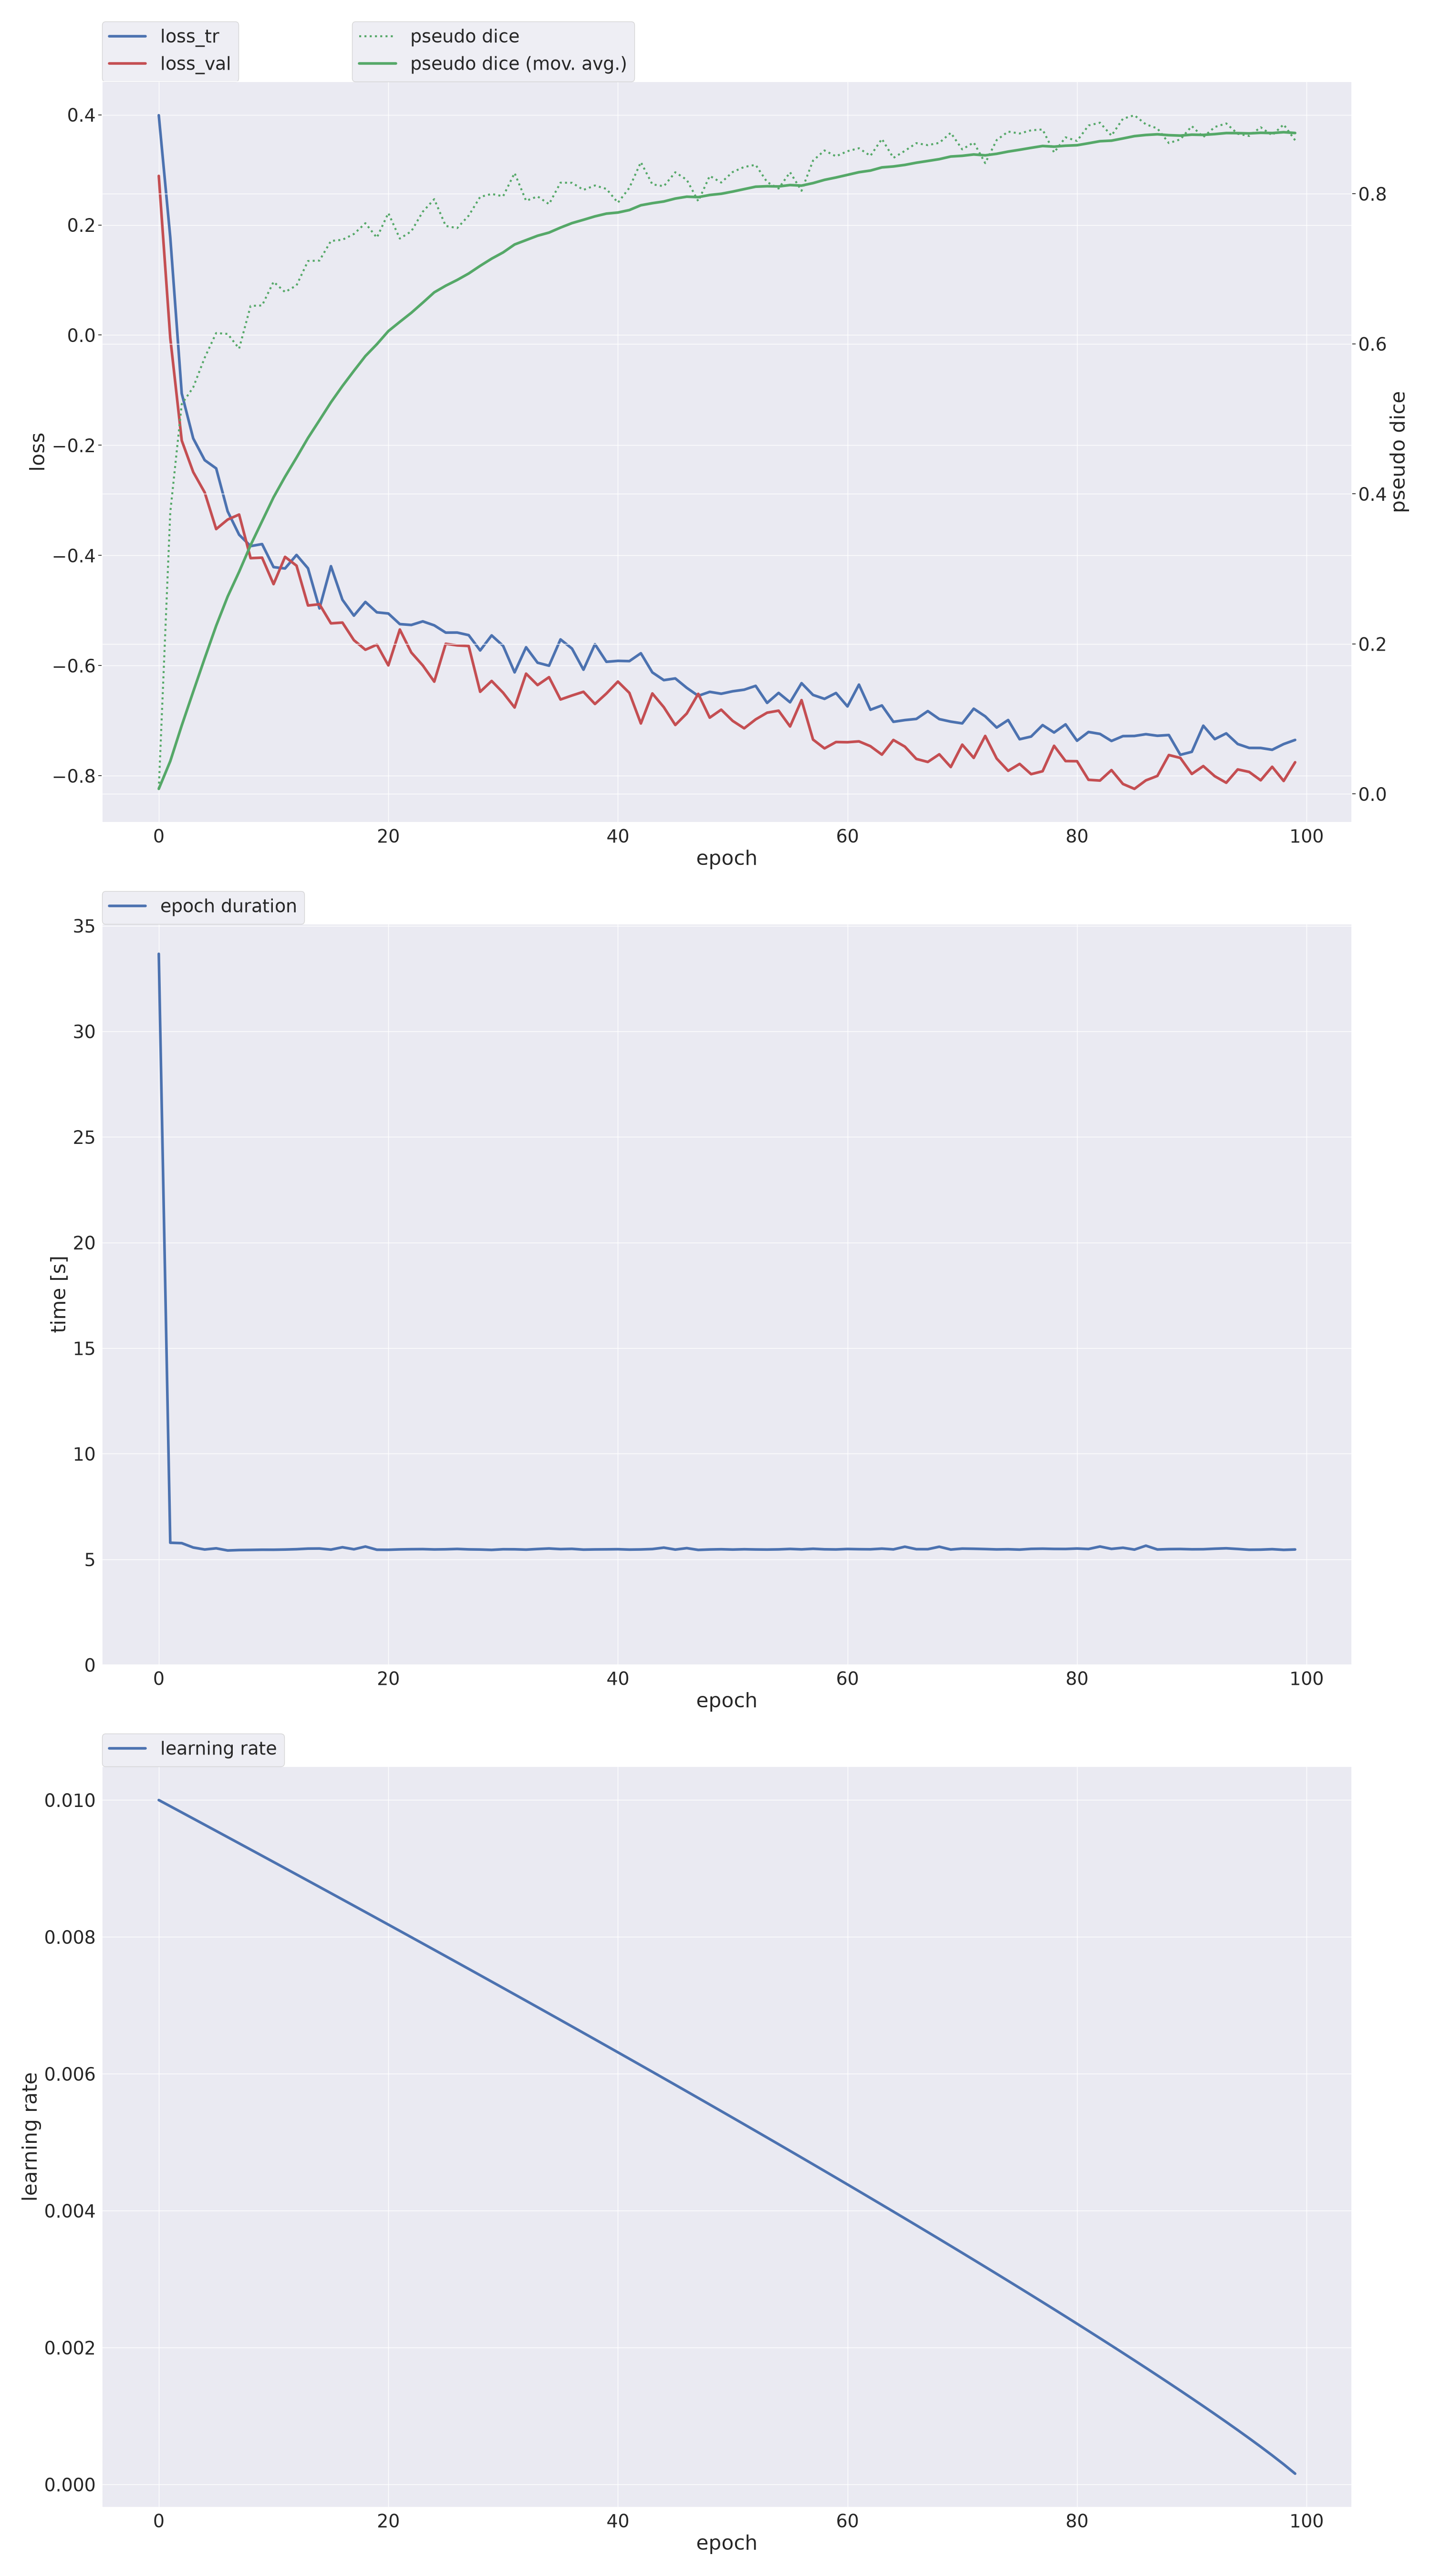

In [10]:
from IPython.display import Image as IPImage, display

progress_png = os.path.join(model_dir, f"fold_{FOLD}", "progress.png")
shutil.copy(progress_png, os.path.join(OUTPUT_DIR, "nnunet_progress.png"))
display(IPImage(filename=progress_png, width=900))

## 11. Predict the test set

`nnUNetv2_predict` on `imagesTs` with the final checkpoint, test-time mirroring disabled
(`--disable_tta`, the other models use no TTA) and `--save_probabilities` so we get the
softmax maps. Then, exactly as in the other notebooks: take the tumour-class probability at
256×256, **upsample it bilinearly to the original image size**, threshold at 0.5, and save
the binary mask to `predictions/` under the original filename (0/255).

As a sanity check we compare our 256×256 thresholded probability with nnU-Net's own
exported segmentation (argmax) — they must agree, which also confirms that the image
orientation is preserved.

In [11]:
raw_pred_dir = os.path.join(NNUNET_HOME, "nnunet_raw_predictions")   # nnU-Net's own output at 256x256
if os.path.isdir(raw_pred_dir):
    shutil.rmtree(raw_pred_dir)
run(["nnUNetv2_predict", "-i", os.path.join(raw_dir, "imagesTs"), "-o", raw_pred_dir,
     "-d", str(DATASET_ID), "-c", CONFIGURATION, "-f", FOLD, "-tr", TRAINER,
     "-chk", "checkpoint_final.pth", "--save_probabilities", "--disable_tta"])

test_cases = mapping_df[mapping_df.split == "test"].set_index("image_name")["case_id"]
pred_masks, max_disagree = {}, 0.0
for name in test_names:
    case = test_cases[name]
    prob = np.load(os.path.join(raw_pred_dir, f"{case}.npz"))["probabilities"][1]   # tumour class
    prob = prob.reshape(prob.shape[-2:]).astype(np.float32)                           # (1,256,256) -> (256,256)
    nn_seg = np.array(Image.open(os.path.join(raw_pred_dir, f"{case}.png")))
    max_disagree = max(max_disagree, np.mean((prob > THRESHOLD) != (nn_seg > 0)))
    H, W = load_image(name).shape
    prob_full = F.interpolate(torch.from_numpy(prob)[None, None], size=(H, W),
                              mode="bilinear", align_corners=False)[0, 0].numpy()
    pred = (prob_full > THRESHOLD).astype(np.uint8)
    pred_masks[name] = pred
    Image.fromarray(pred * 255).save(os.path.join(PRED_DIR, name))
print(f"saved {len(pred_masks)} predicted masks to {PRED_DIR}/")
print(f"max pixel disagreement with nnU-Net's own argmax export: {max_disagree:.5f}")
assert max_disagree < 0.001

$ nnUNetv2_predict -i /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnUNet_raw/Dataset501_BUSI/imagesTs -o /mnt/cv_data/users/hahaxixi/projects/research_training/task6_nnunet/nnunet_raw_predictions -d 501 -c 2d -f all -tr nnUNetTrainer_BUSIfair -chk checkpoint_final.pth --save_probabilities --disable_tta


/mnt/cv_data/users/hahaxixi/envs/ml/lib/python3.11/site-packages/torch/jit/_script.py:1643: FutureWarning: `torch.jit.interface` is deprecated. Please use `torch.compile` instead.
  warnings.warn(



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 130 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 130 cases that I would like to predict



Predicting BUSI_518:
perform_everything_on_device: True



100%|██████████| 1/1 [00:00<00:00,  1.00it/s]
sending off prediction to background worker for resampling and export
done with BUSI_518

Predicting BUSI_519:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 166.12it/s]
sending off prediction to background worker for resampling and export
done with BUSI_519

Predicting BUSI_520:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 171.37it/s]
sending off prediction to background worker for resampling and export
done with BUSI_520

Predicting BUSI_521:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 167.02it/s]
sending off prediction to background worker for resampling and export
done with BUSI_521

Predicting BUSI_522:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 169.73it/s]


...

sending off prediction to background worker for resampling and export
done with BUSI_641

Predicting BUSI_642:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 164.37it/s]


sending off prediction to background worker for resampling and export
done with BUSI_642

Predicting BUSI_643:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 164.86it/s]
sending off prediction to background worker for resampling and export
done with BUSI_643

Predicting BUSI_644:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 157.97it/s]
sending off prediction to background worker for resampling and export
done with BUSI_644

Predicting BUSI_645:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 166.35it/s]


sending off prediction to background worker for resampling and export
done with BUSI_645

Predicting BUSI_646:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 146.98it/s]
sending off prediction to background worker for resampling and export
done with BUSI_646

Predicting BUSI_647:
perform_everything_on_device: True

100%|██████████| 1/1 [00:00<00:00, 162.66it/s]
sending off prediction to background worker for resampling and export
done with BUSI_647
GPU prediction completed. Waiting for remaining segmentation exports to finish...



Segmentation export complete.


saved 130 predicted masks to predictions/
max pixel disagreement with nnU-Net's own argmax export: 0.00000


## 12. Test-set metrics: Dice, IoU, HD95

For a predicted mask P and ground truth G (both at original resolution):

- **Dice** = 2|P∩G| / (|P| + |G|) — overlap, 0 (none) … 1 (perfect).
- **IoU** (Jaccard) = |P∩G| / |P∪G| — stricter overlap; IoU = Dice / (2 − Dice).
- **HD95** = 95th percentile of the symmetric surface distances between the boundaries of
  P and G, in **pixels** (BUSI has no physical spacing). Lower is better; it measures how
  far the predicted boundary strays, which Dice barely notices. Computed with
  `medpy.metric.binary.hd95`.

**Empty-prediction rule (same in all three notebooks):** if the model predicts no tumour
pixel at all, HD95 is undefined. We set **HD95 = diagonal of the original image**
(`sqrt(H² + W²)`, the largest distance possible in that image) and Dice = IoU = 0. We do
not drop those images (NaN), because the paired statistical tests in Task 8 need every
model to have a value for every test image. The number of empty predictions is printed.

Per-image results are written to `per_image_metrics.csv` (columns `image_name, dice, iou,
hd95`) in the `test.xlsx` order, which is identical for all three models.

In [12]:
def segmentation_metrics(pred, gt):
    """Return (dice, iou, hd95, is_empty) for binary masks of the same shape."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = 2.0 * inter / (pred.sum() + gt.sum())
    iou = inter / union
    if pred.sum() == 0:                       # empty prediction -> worst-case HD95
        return 0.0, 0.0, float(np.hypot(*gt.shape)), True
    return float(dice), float(iou), float(medpy_binary.hd95(pred, gt)), False


rows, n_empty_pred = [], 0
for name in test_names:
    d, j, h, empty = segmentation_metrics(pred_masks[name], load_mask(name))
    n_empty_pred += empty
    rows.append({"image_name": name, "dice": d, "iou": j, "hd95": h})
metrics_df = pd.DataFrame(rows, columns=["image_name", "dice", "iou", "hd95"])
metrics_df.to_csv(METRICS_CSV, index=False)

summary = {m: {"mean": float(metrics_df[m].mean()), "std": float(metrics_df[m].std(ddof=1))}
           for m in ["dice", "iou", "hd95"]}
summary["n_test"] = len(metrics_df)
summary["n_empty_predictions"] = int(n_empty_pred)
with open(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_test_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"{MODEL_LABEL} on {len(metrics_df)} test images (mean ± sample std):")
for m in ["dice", "iou", "hd95"]:
    print(f"  {m:5s} {summary[m]['mean']:.4f} ± {summary[m]['std']:.4f}")
print(f"  empty predictions: {n_empty_pred} / {len(metrics_df)} (HD95 set to image diagonal)")
print(f"per-image metrics -> {METRICS_CSV}")

nnU-Net on 130 test images (mean ± sample std):
  dice  0.7797 ± 0.2388
  iou   0.6874 ± 0.2530
  hd95  70.7803 ± 114.1804
  empty predictions: 1 / 130 (HD95 set to image diagonal)
per-image metrics -> per_image_metrics.csv


## 13. Per-image visual check of every test image

One row per test image, in `test.xlsx` order: original image, ground-truth mask, predicted
mask, and an overlay (ground-truth contour in yellow, prediction filled and outlined in
this model's colour). The row title gives that image's Dice / IoU / HD95. Images are
shown 10 per figure.

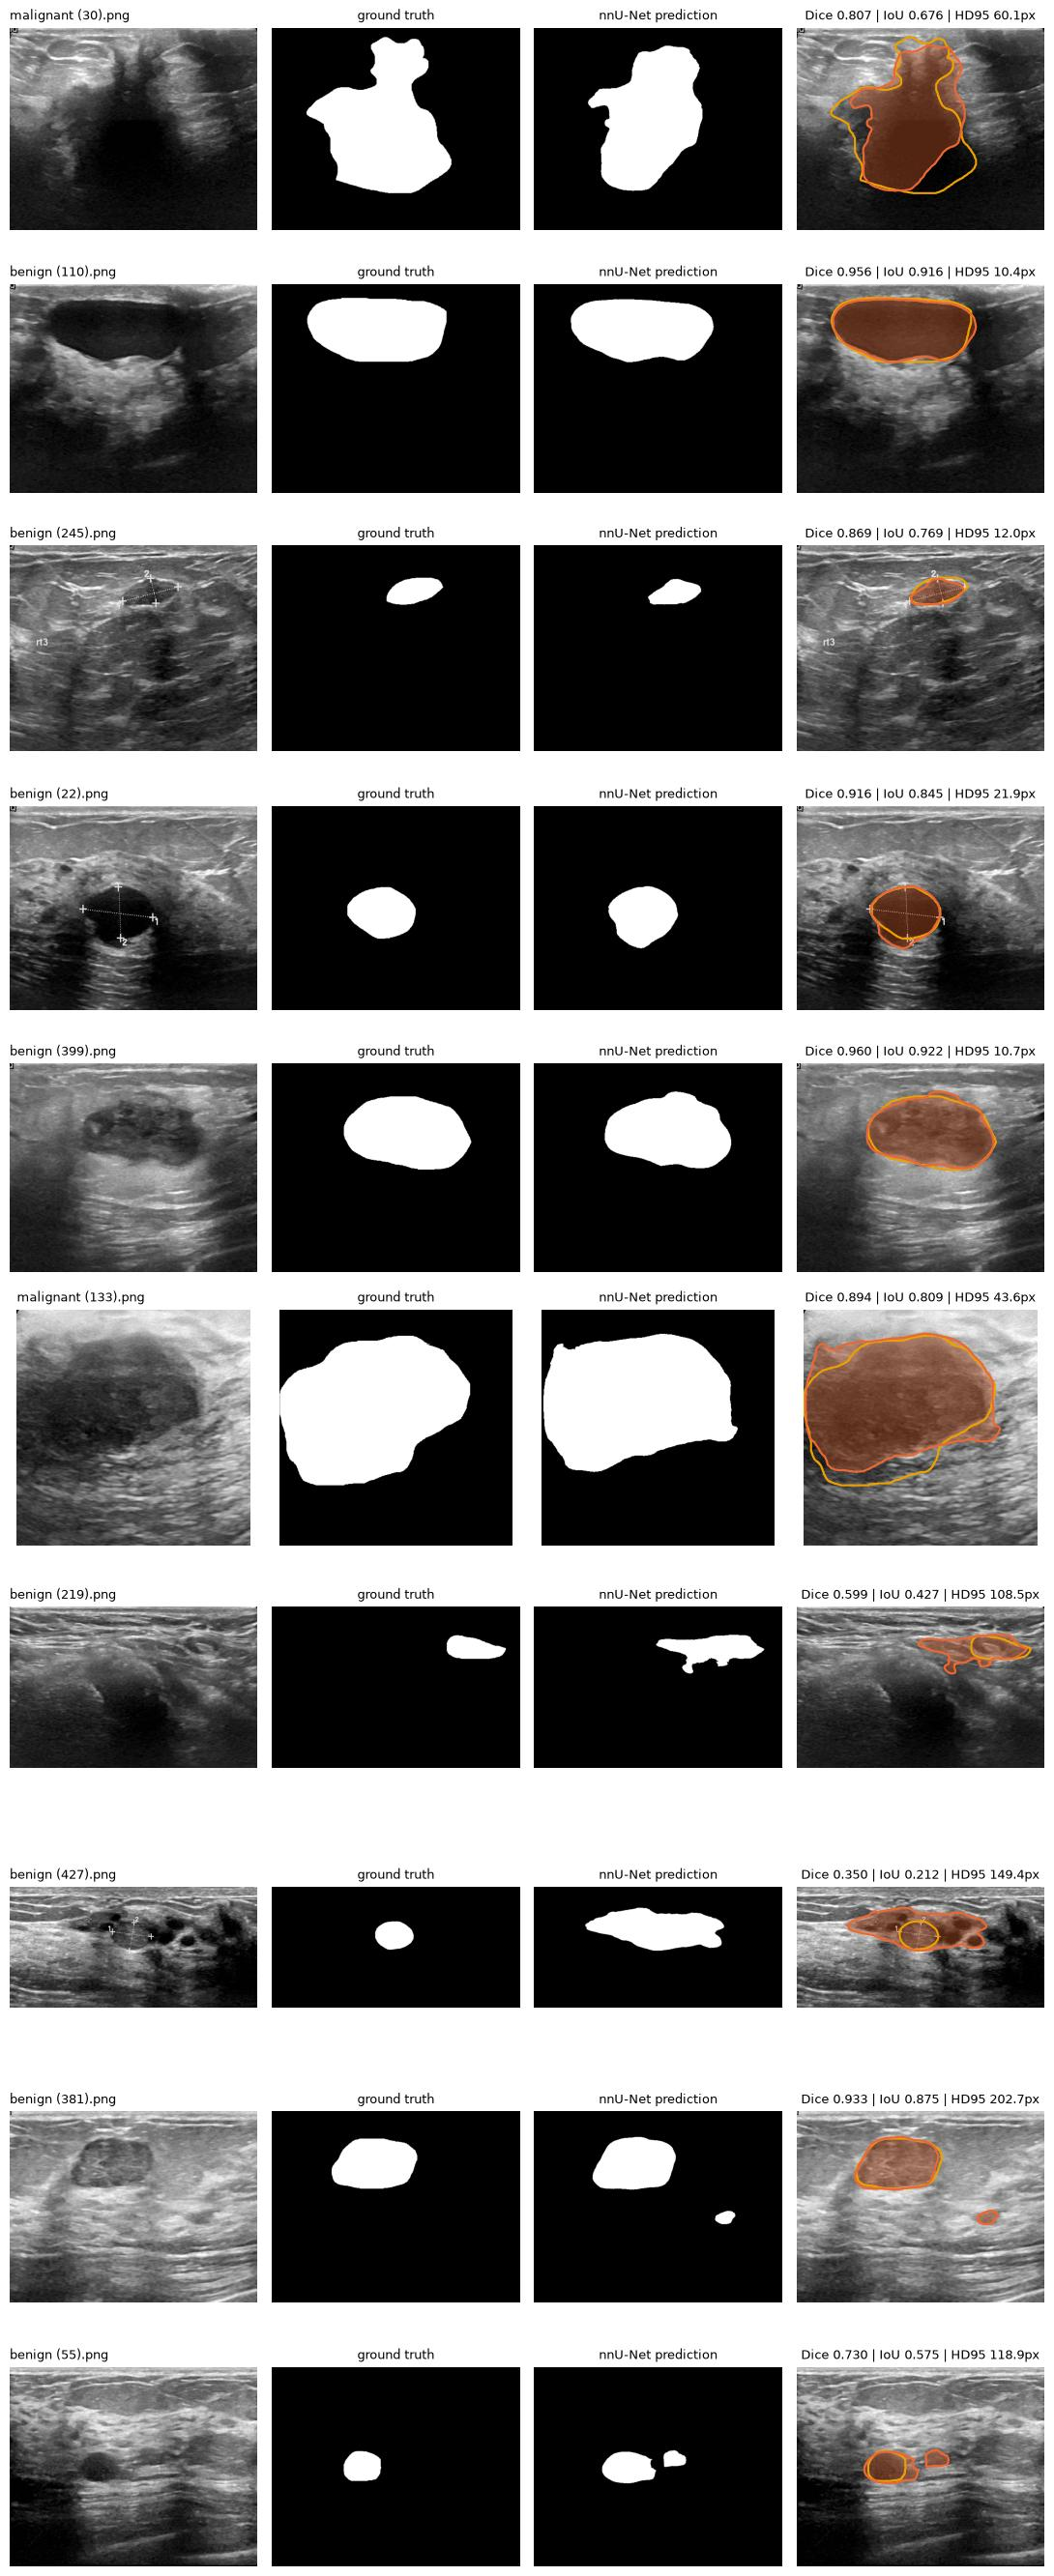

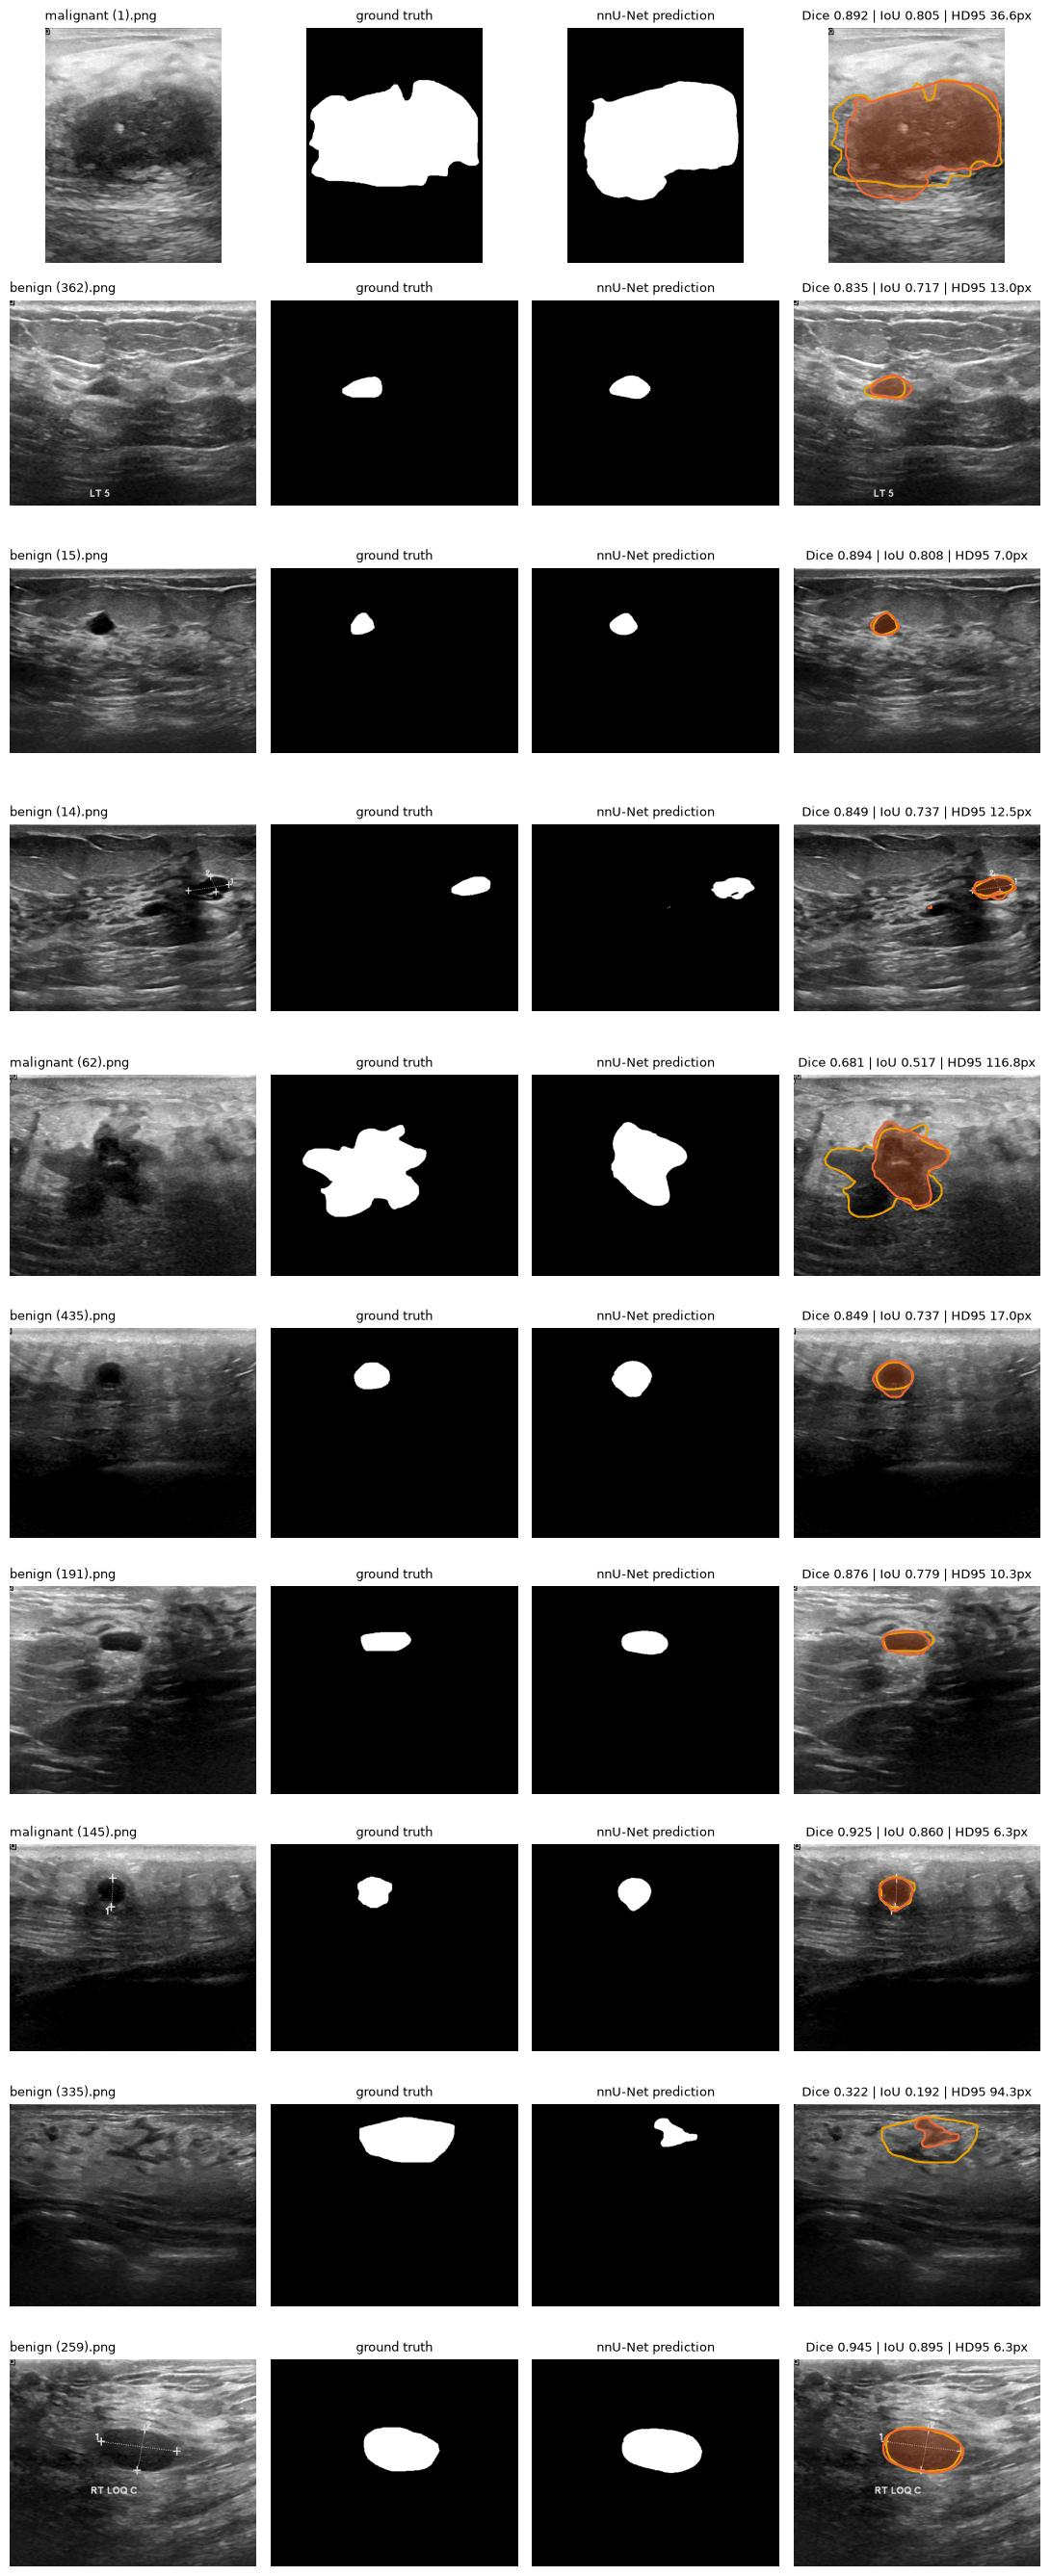

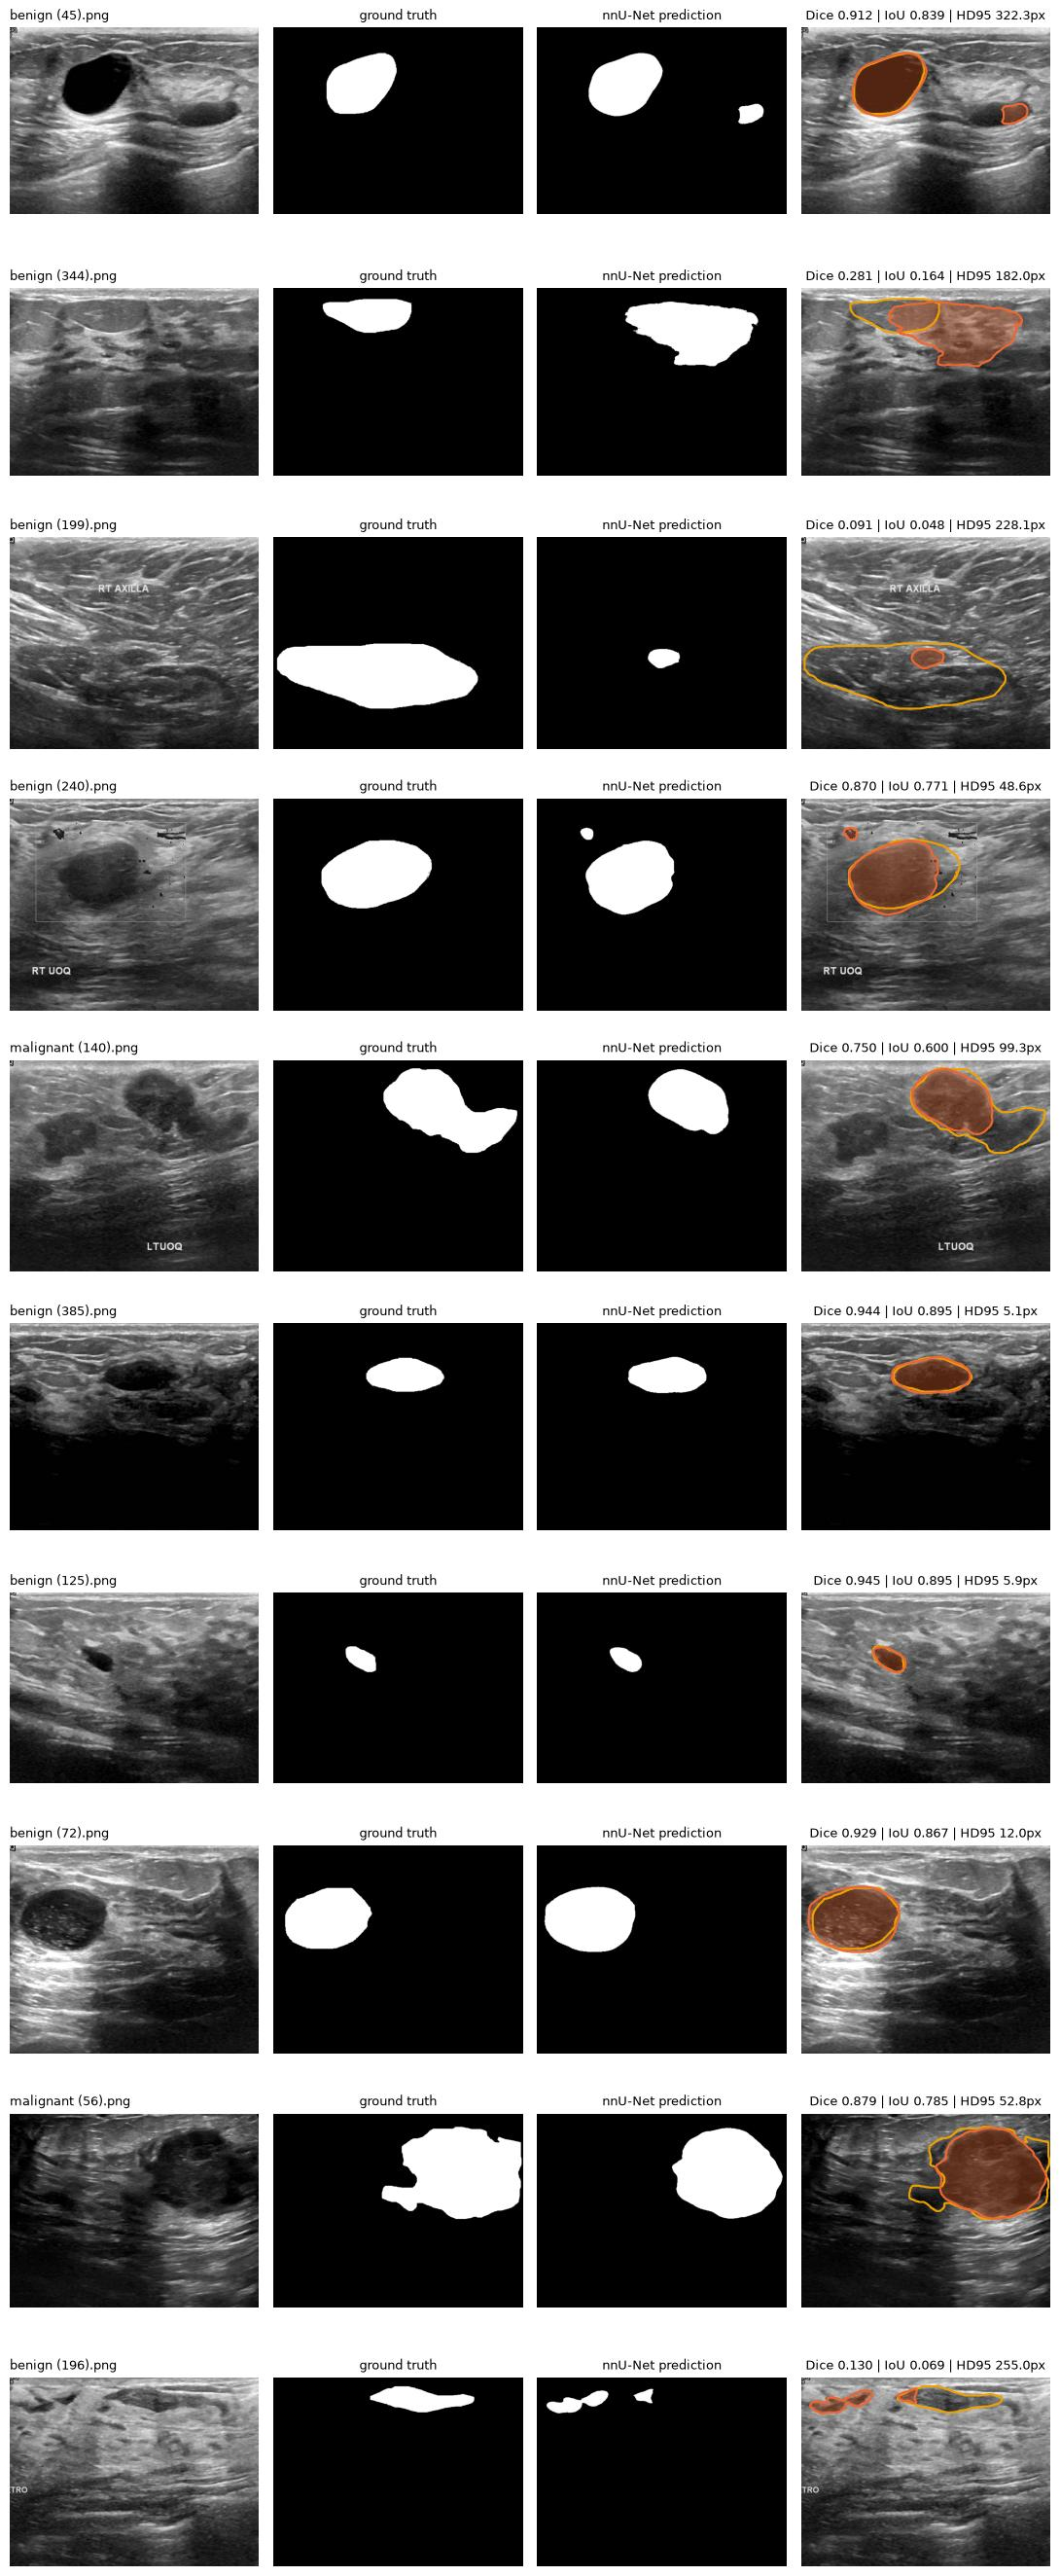

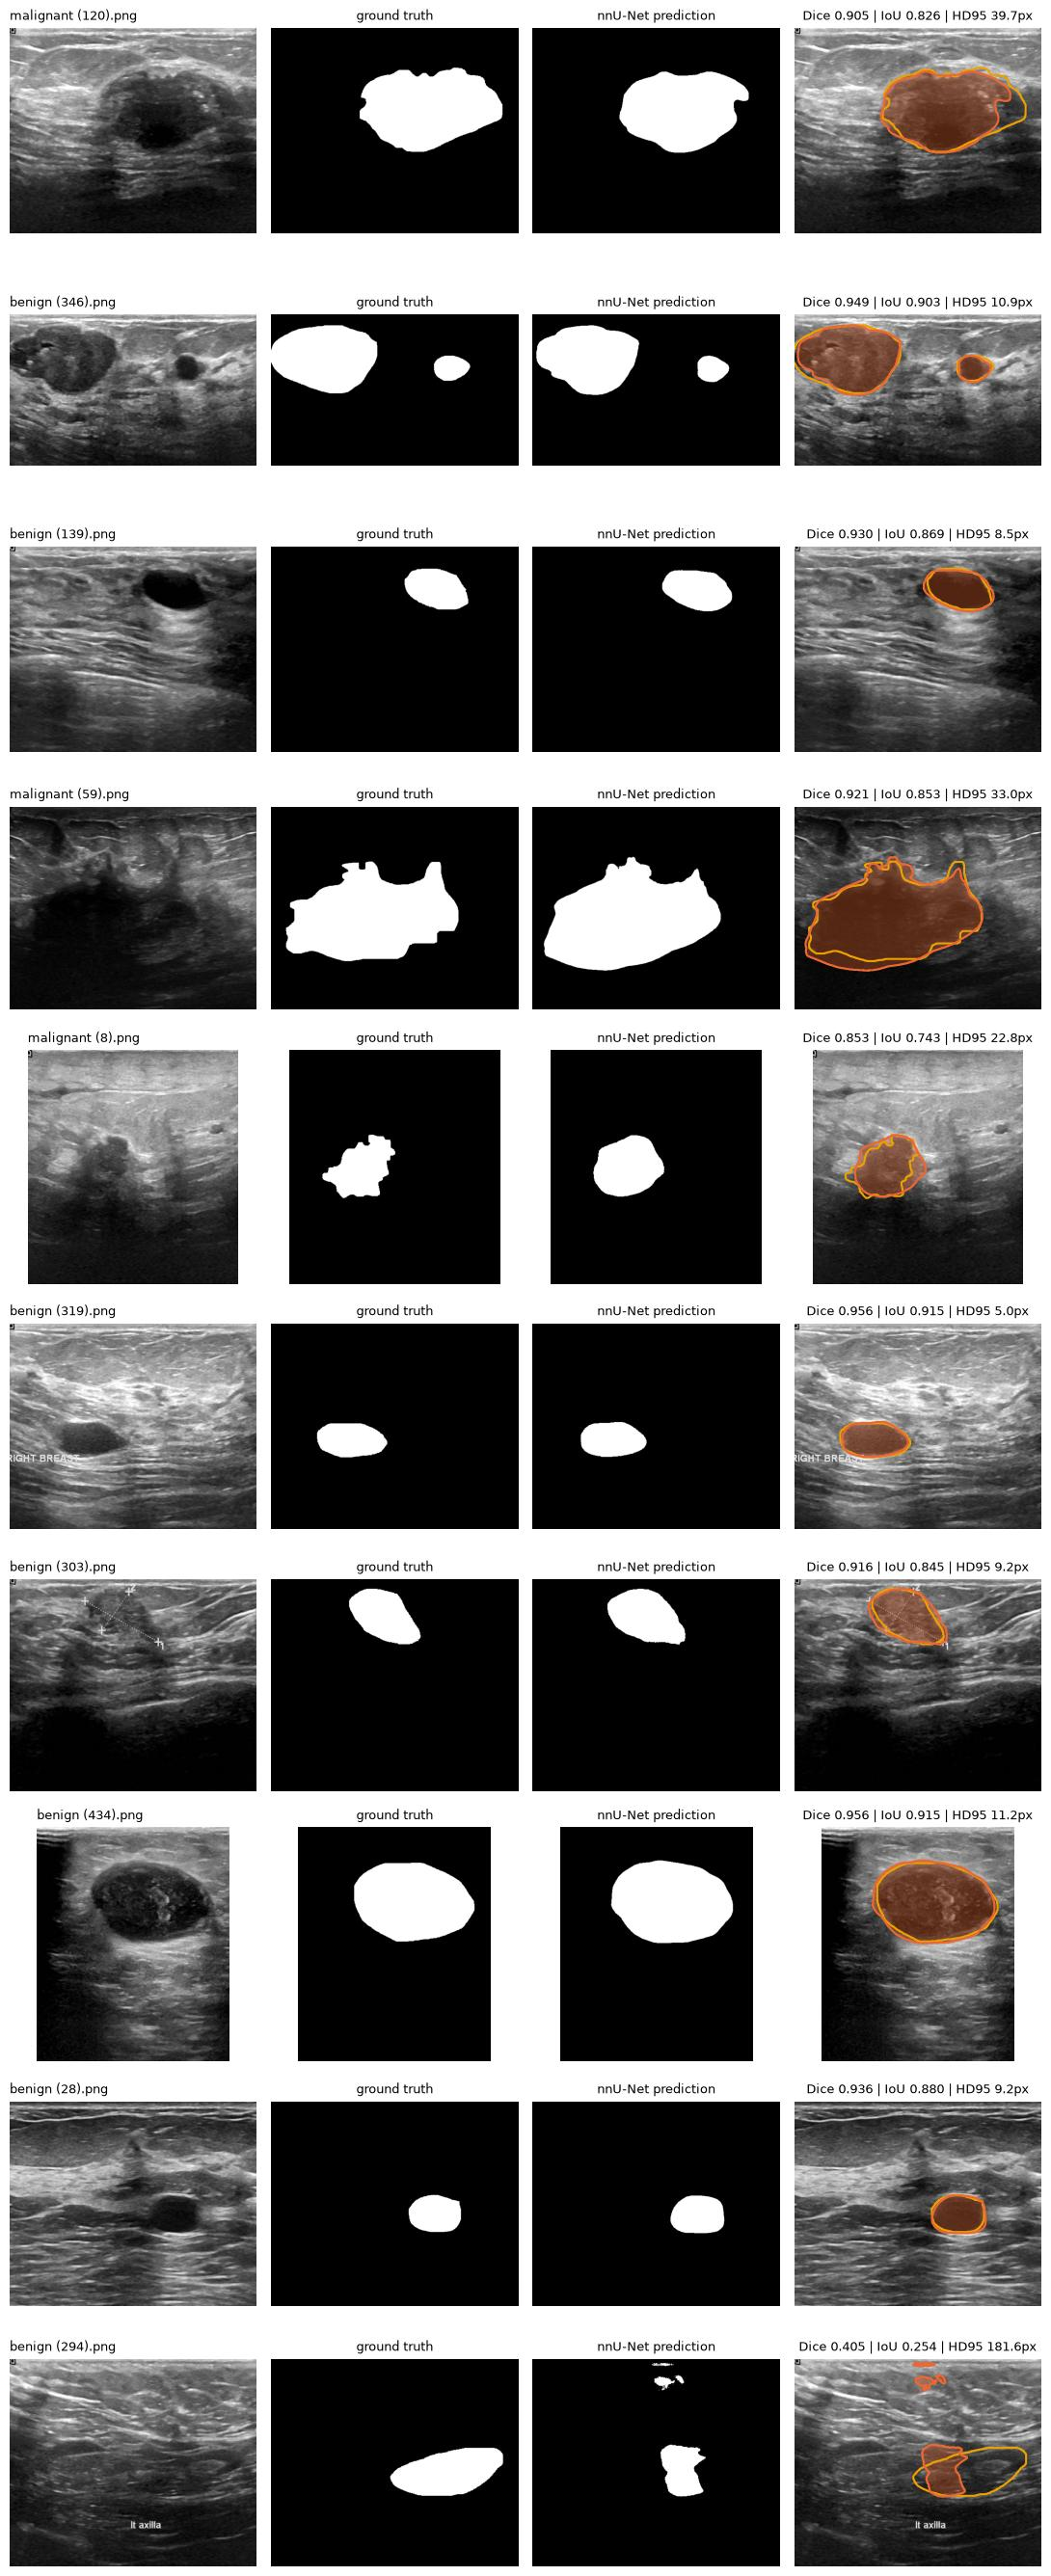

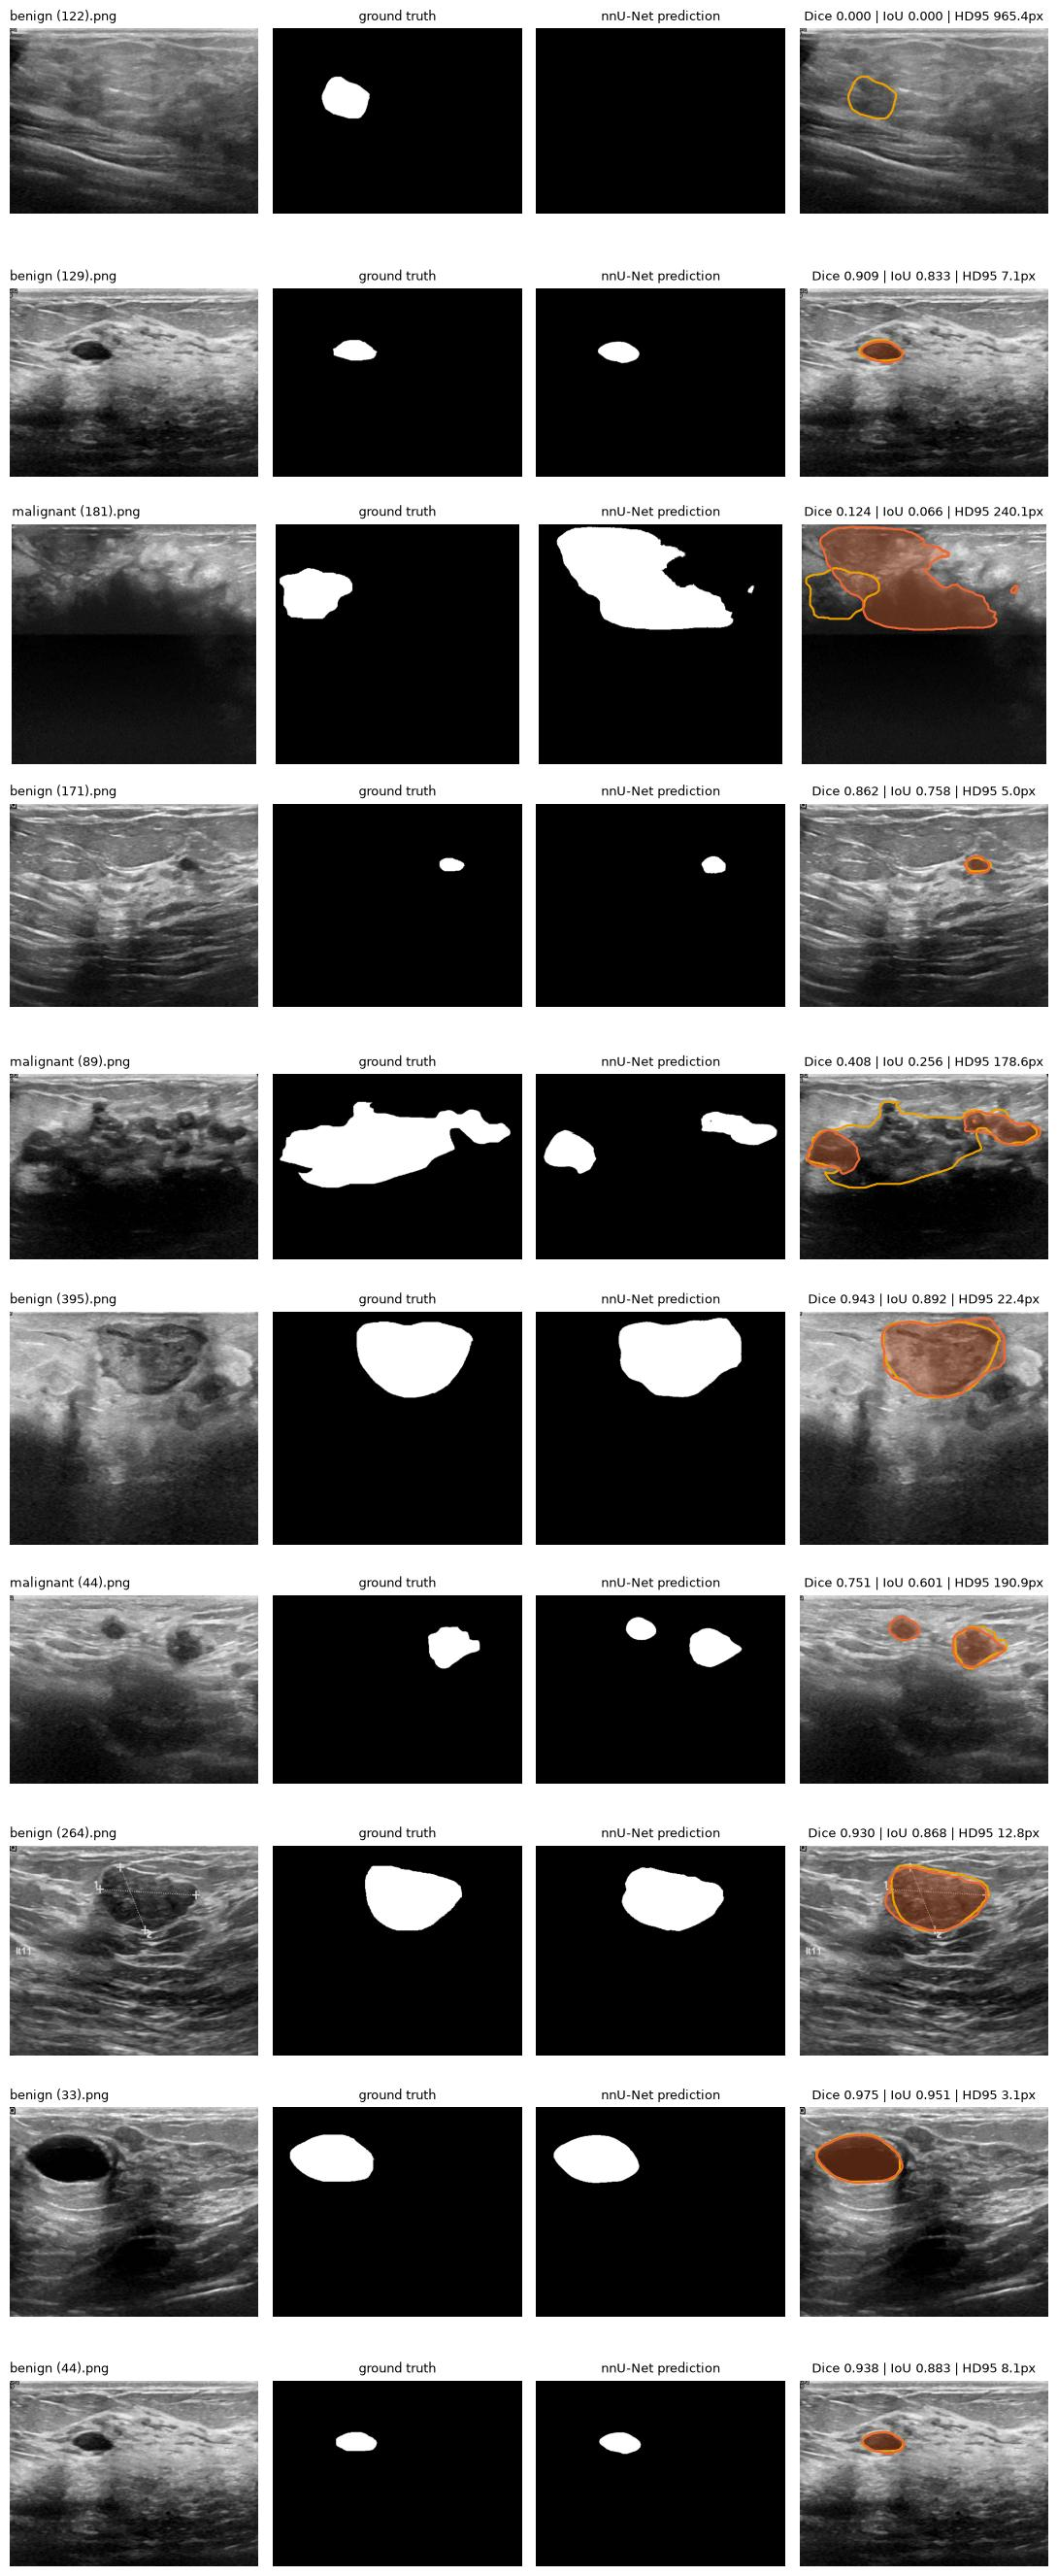

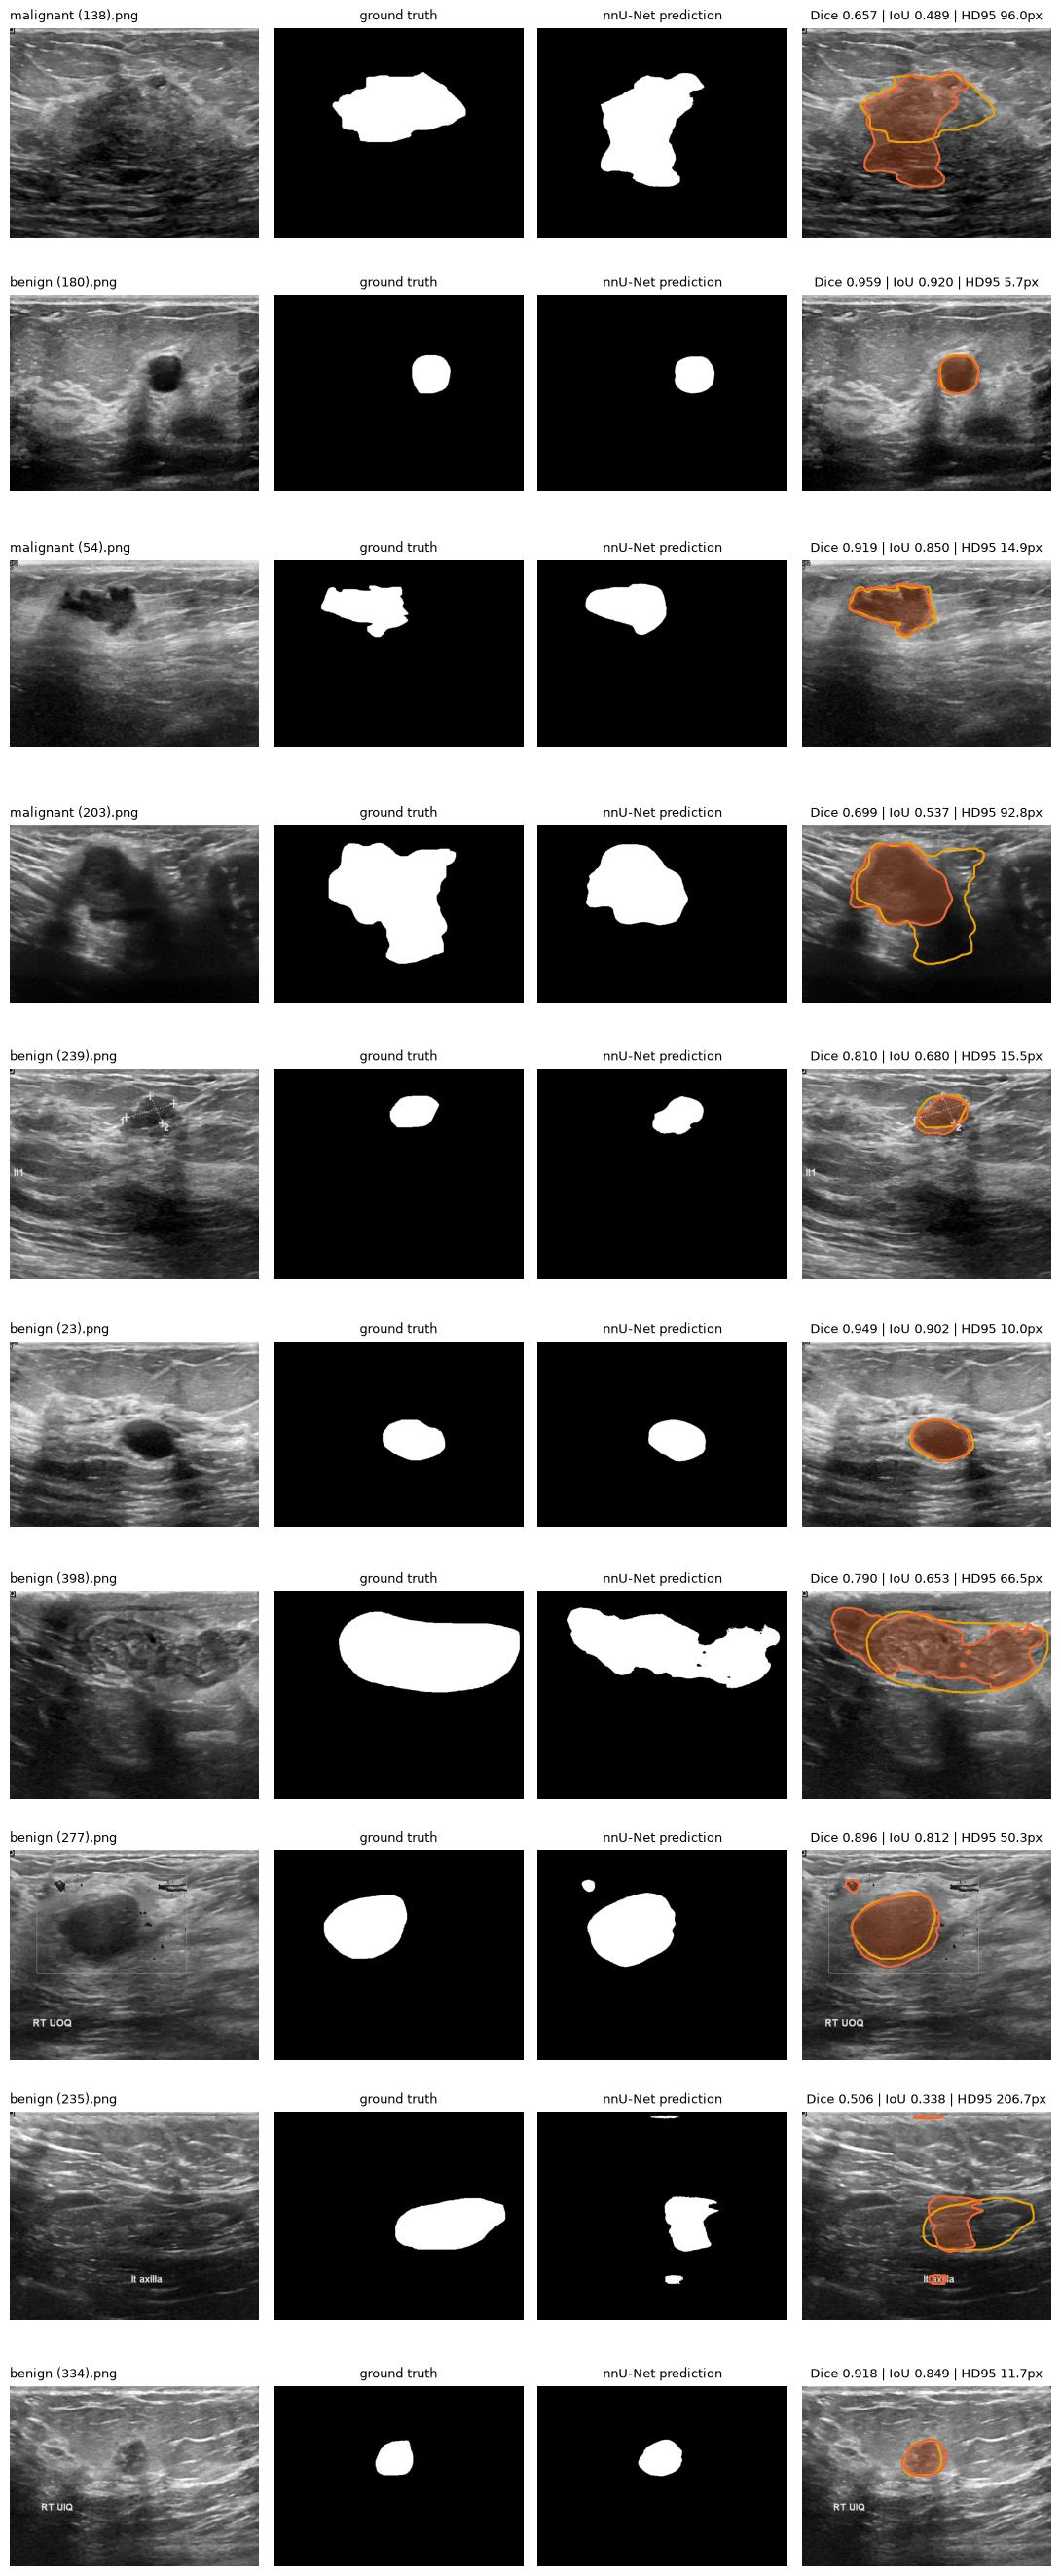

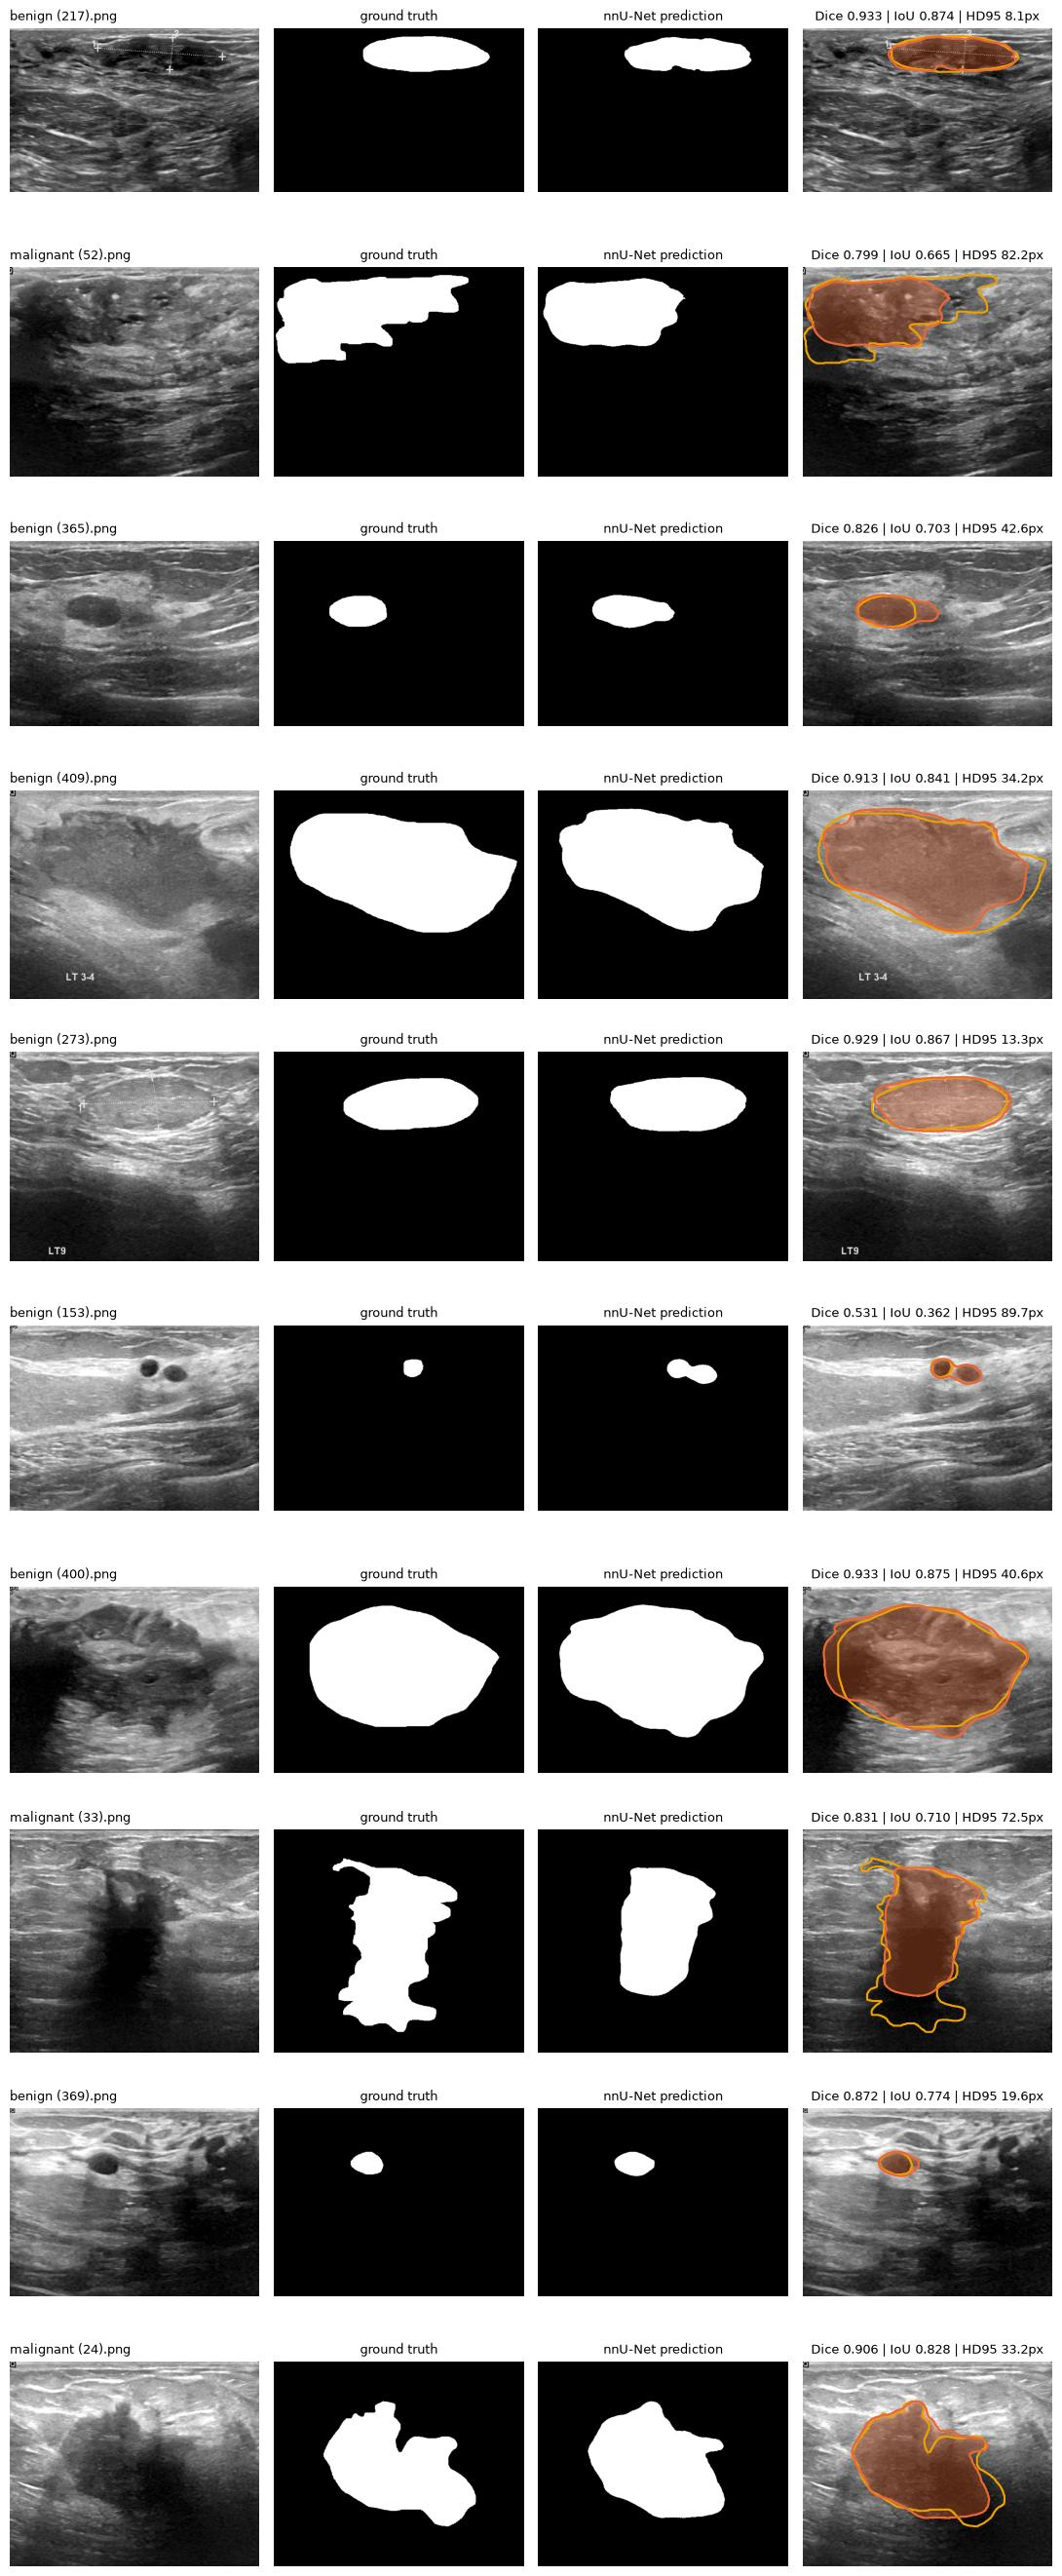

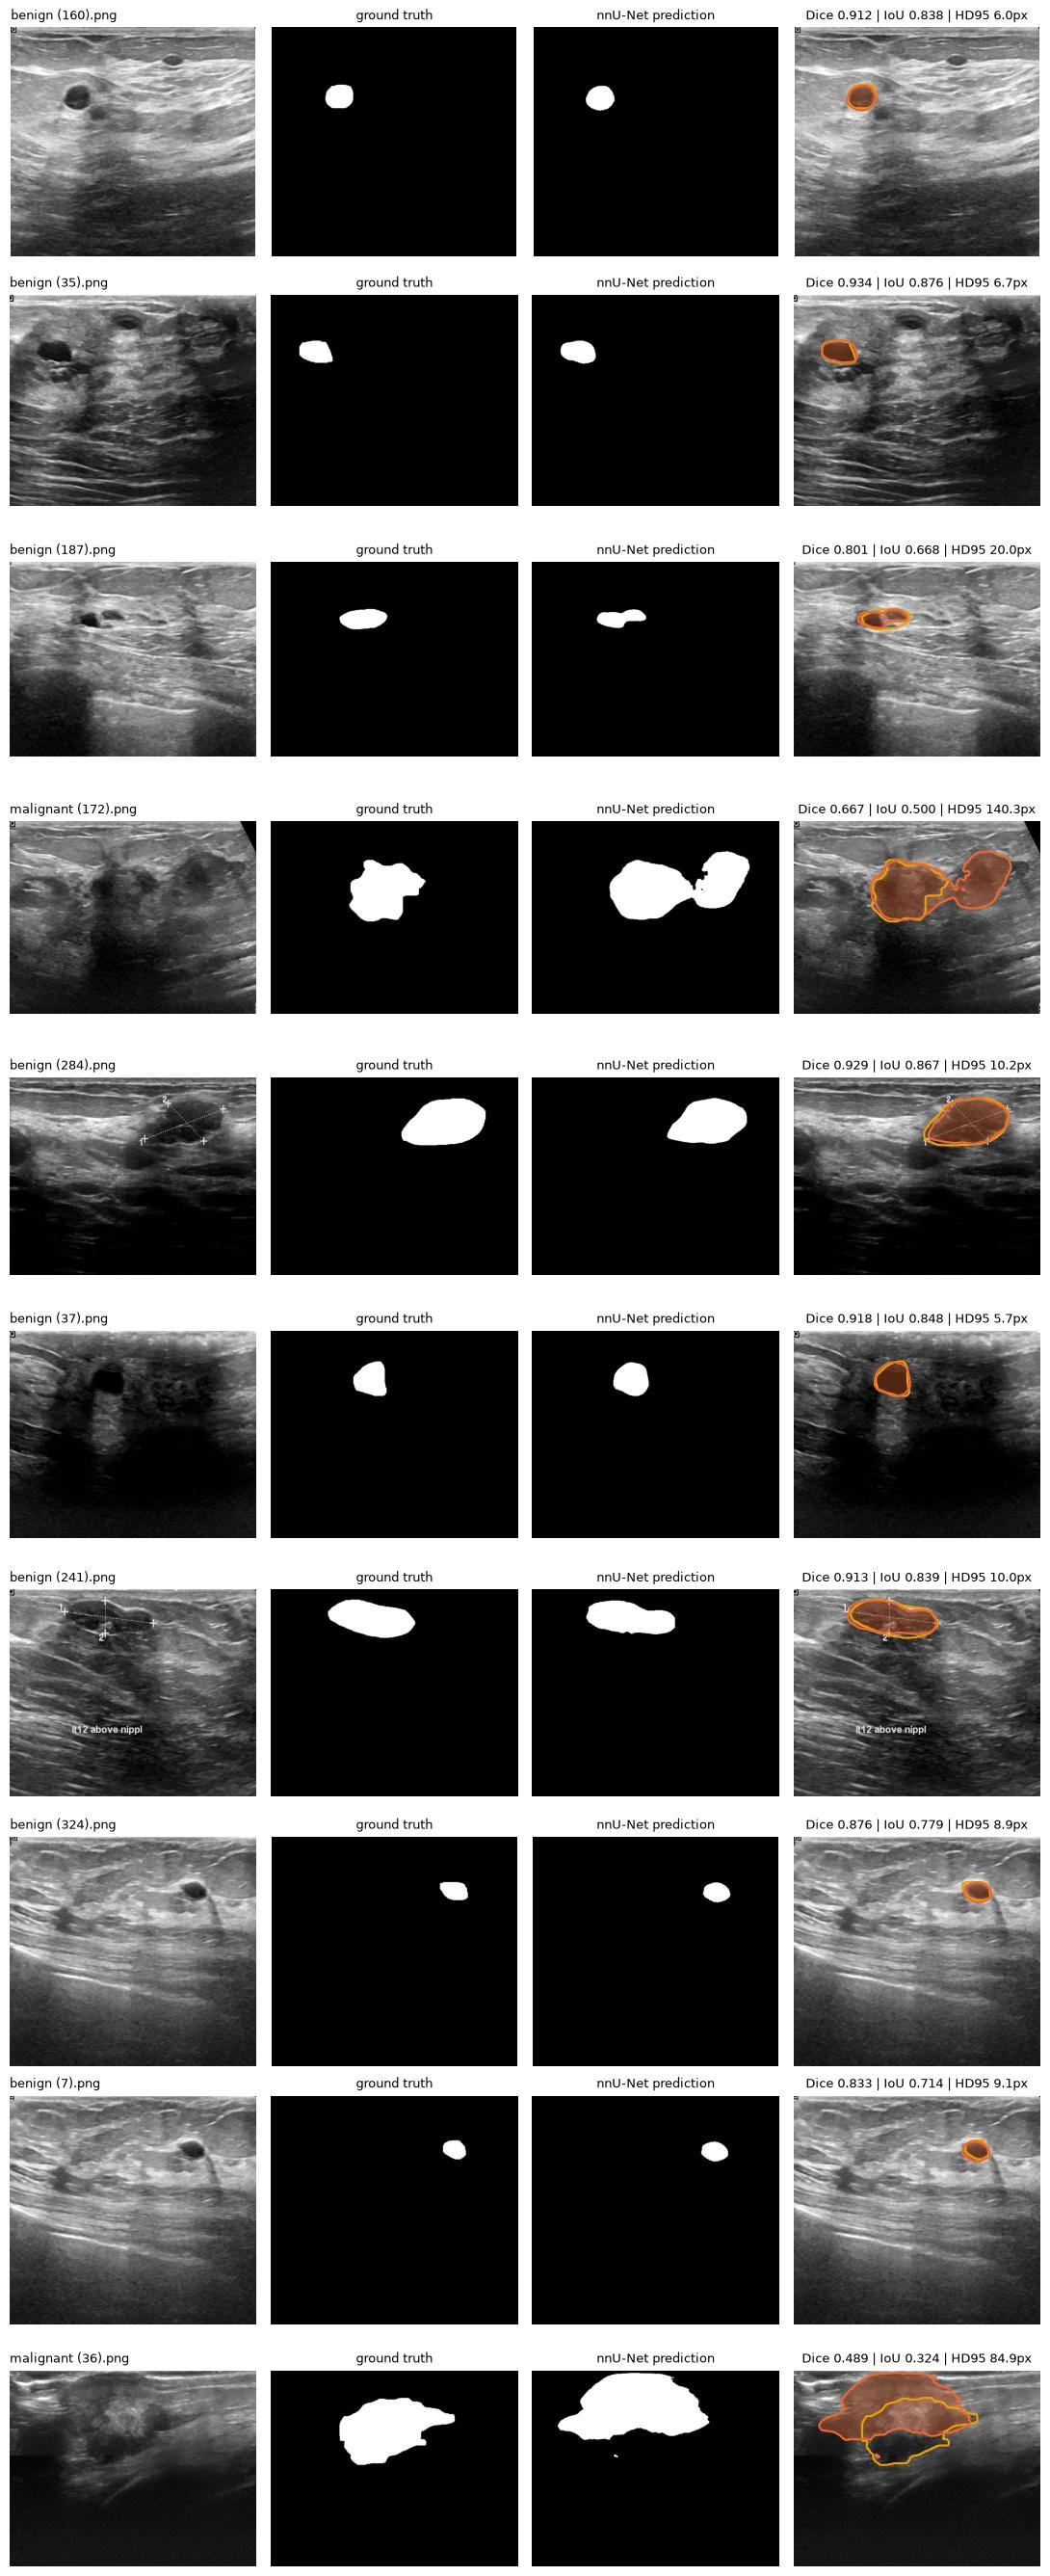

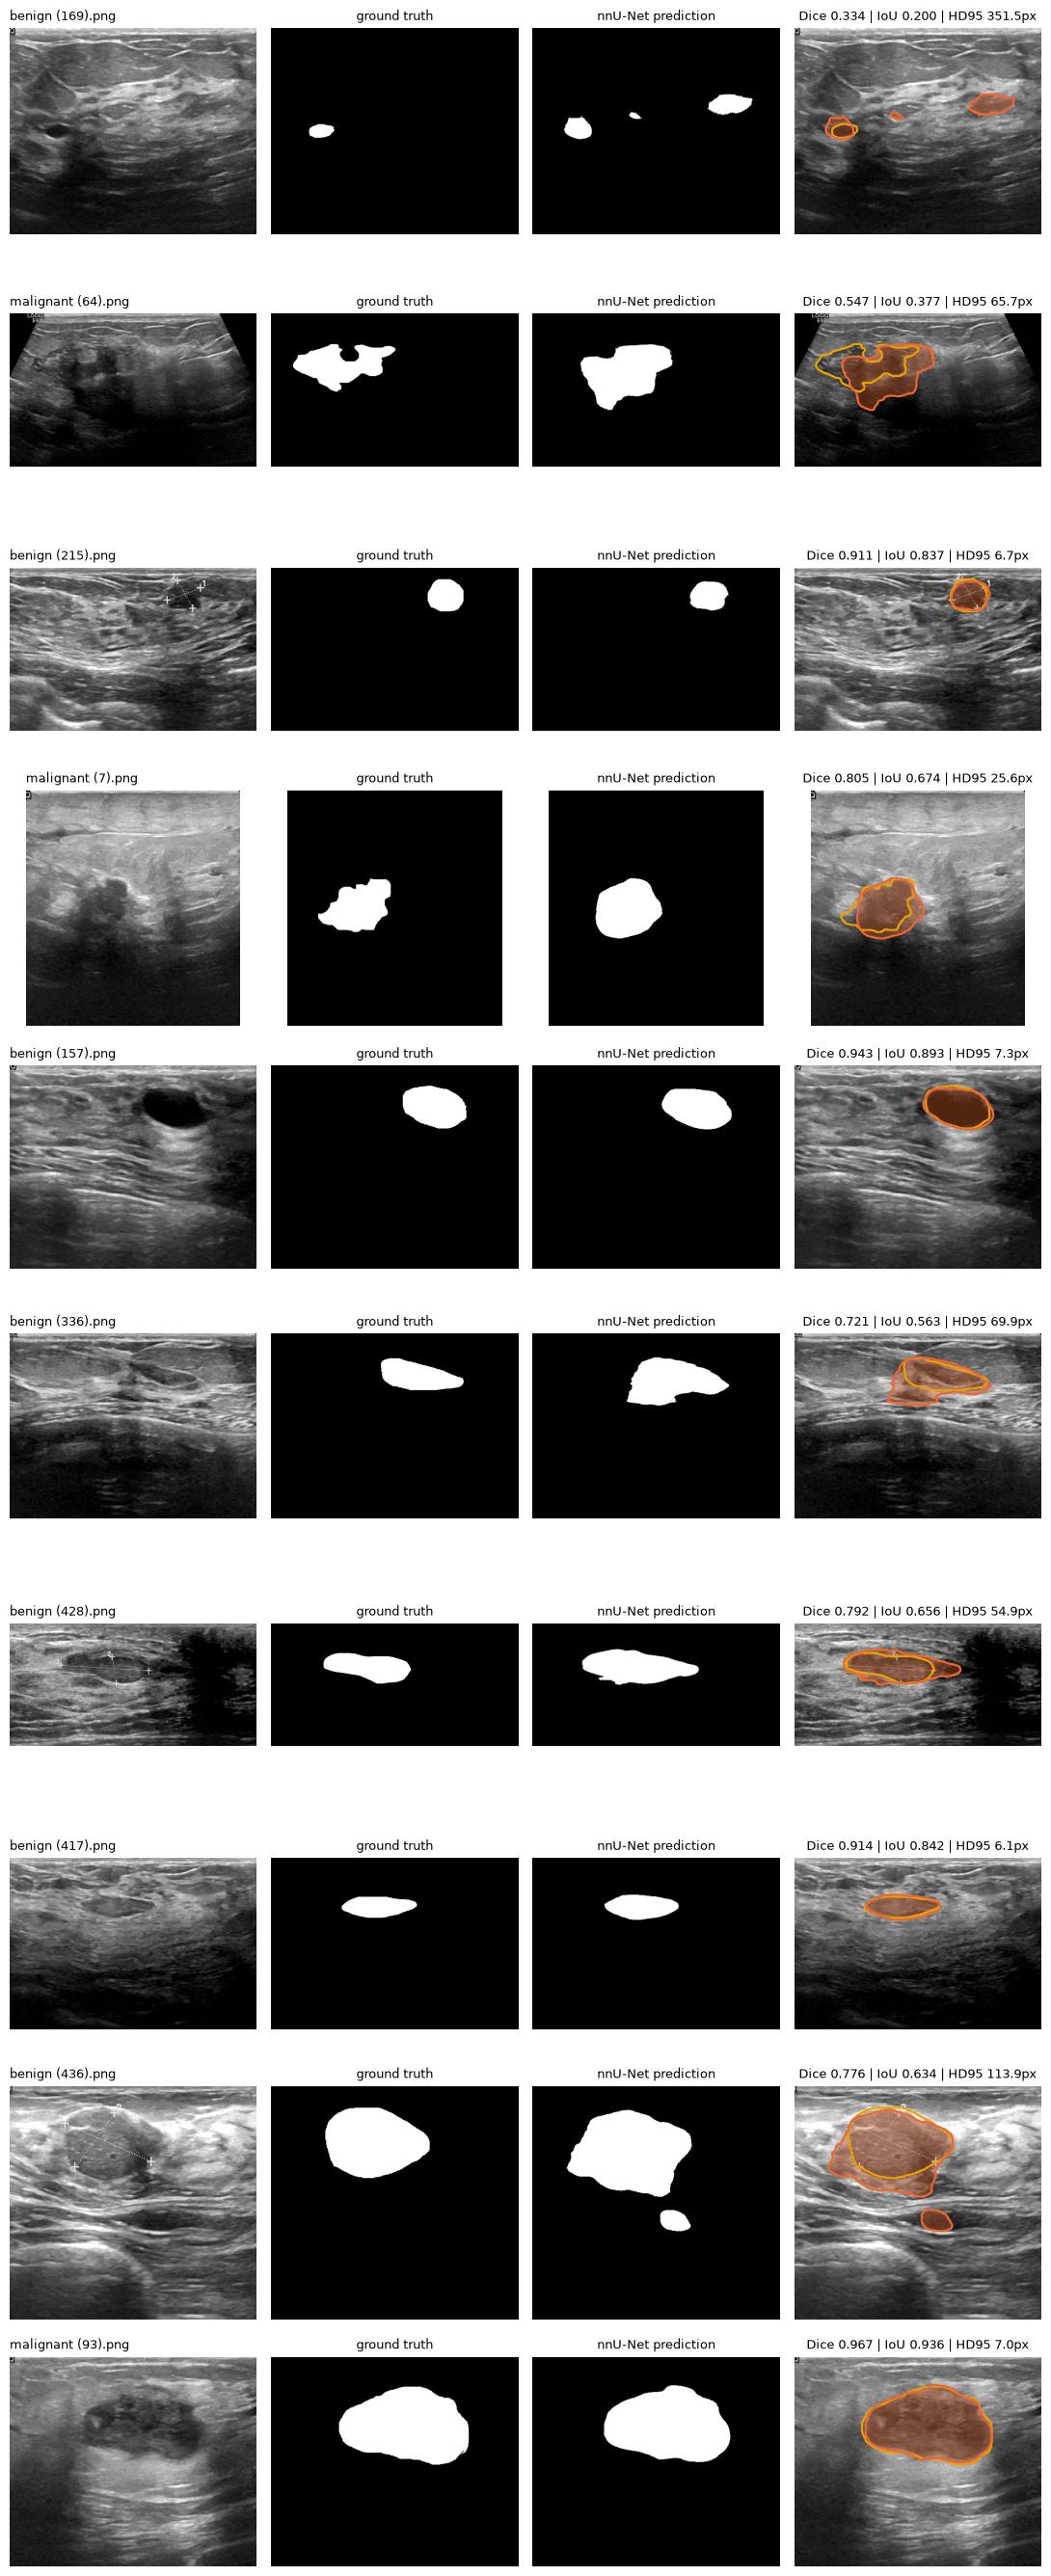

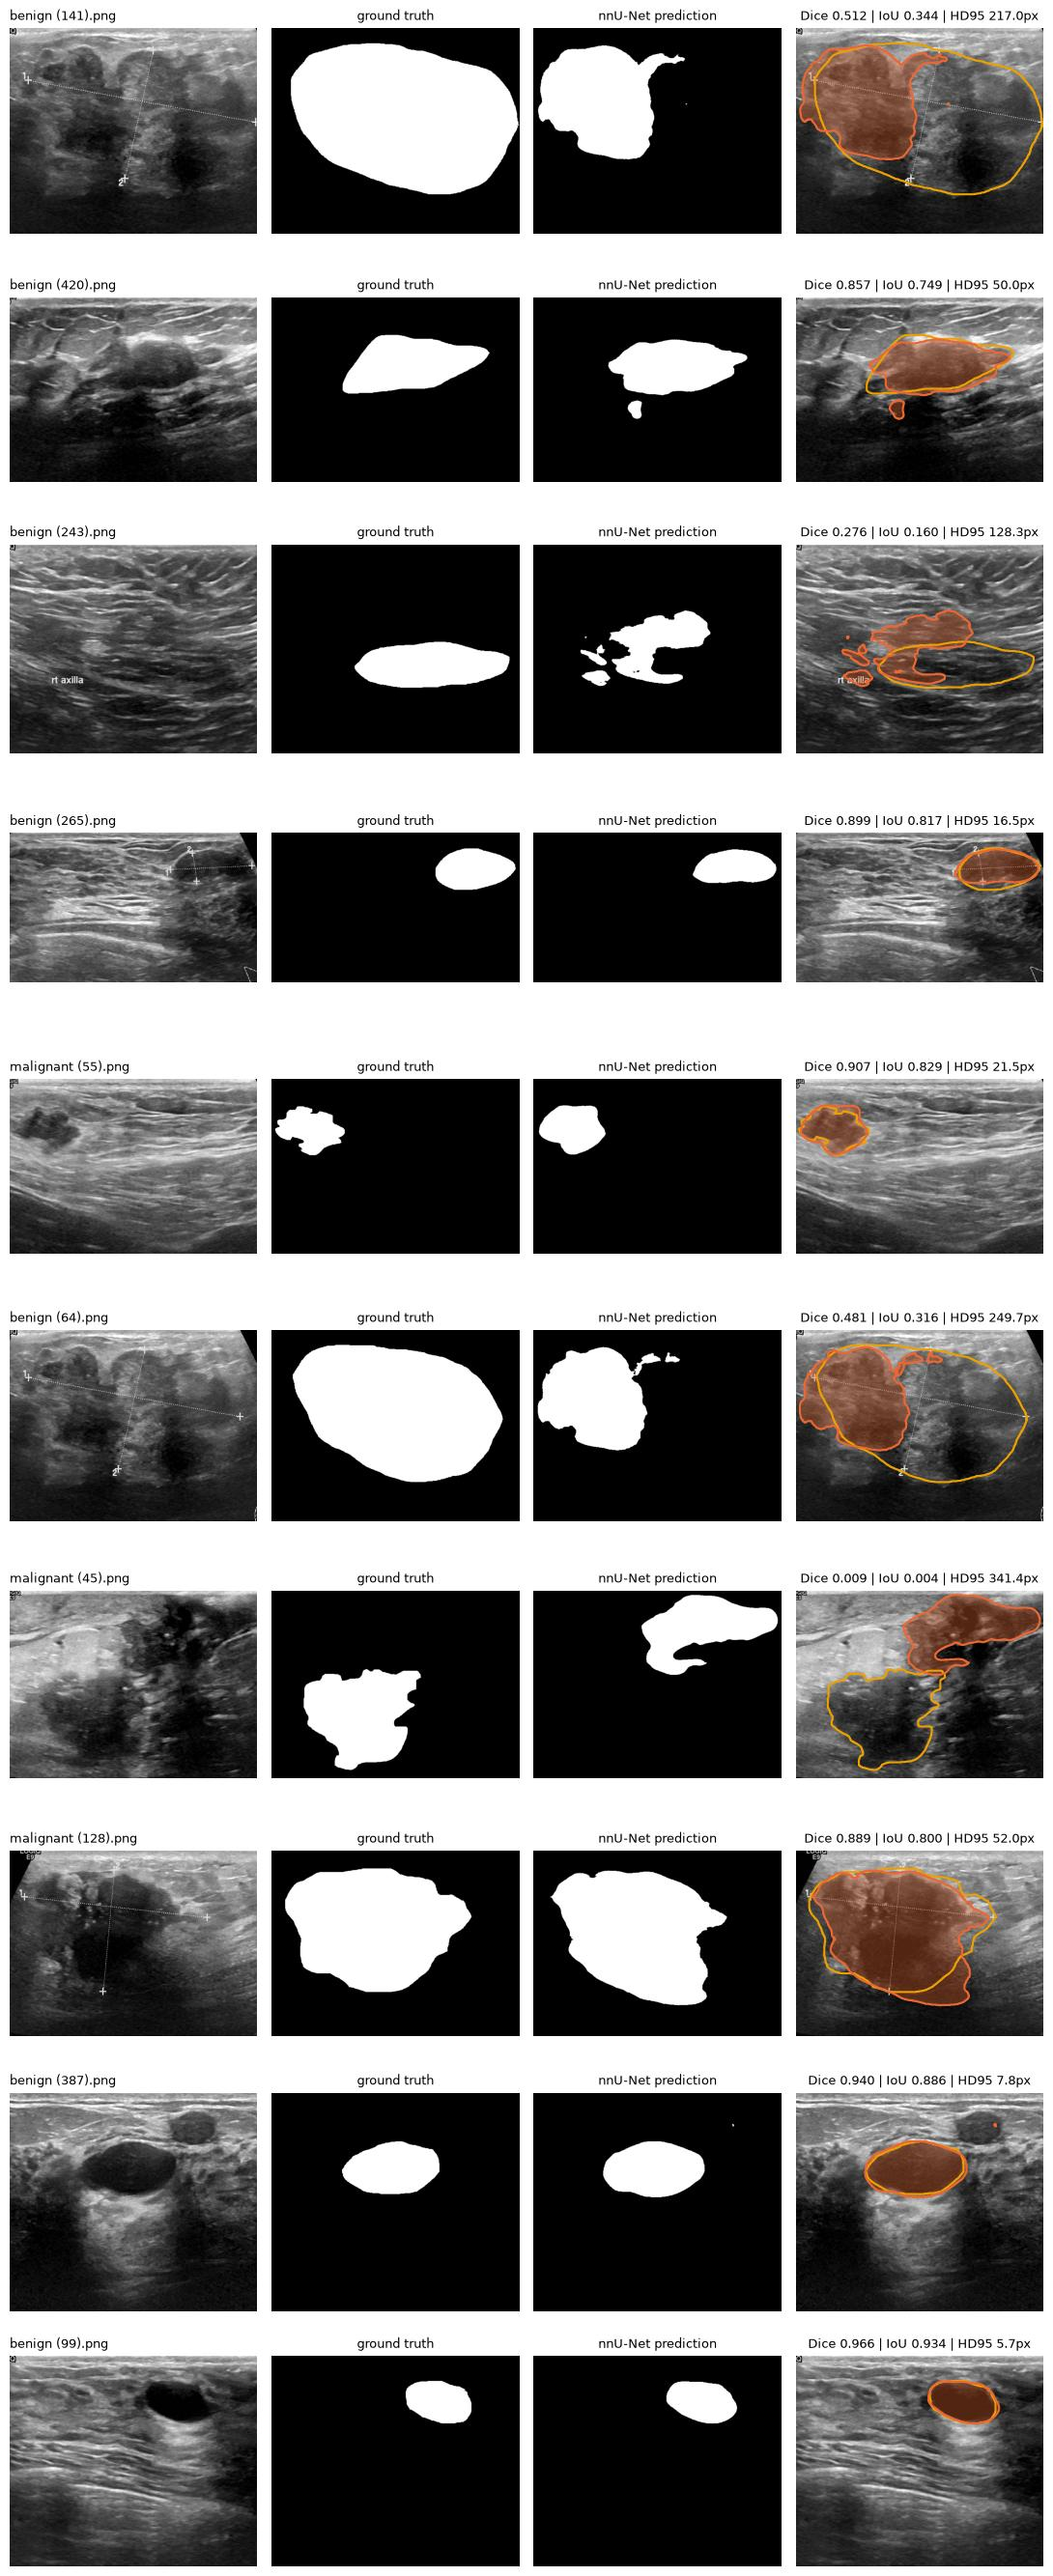

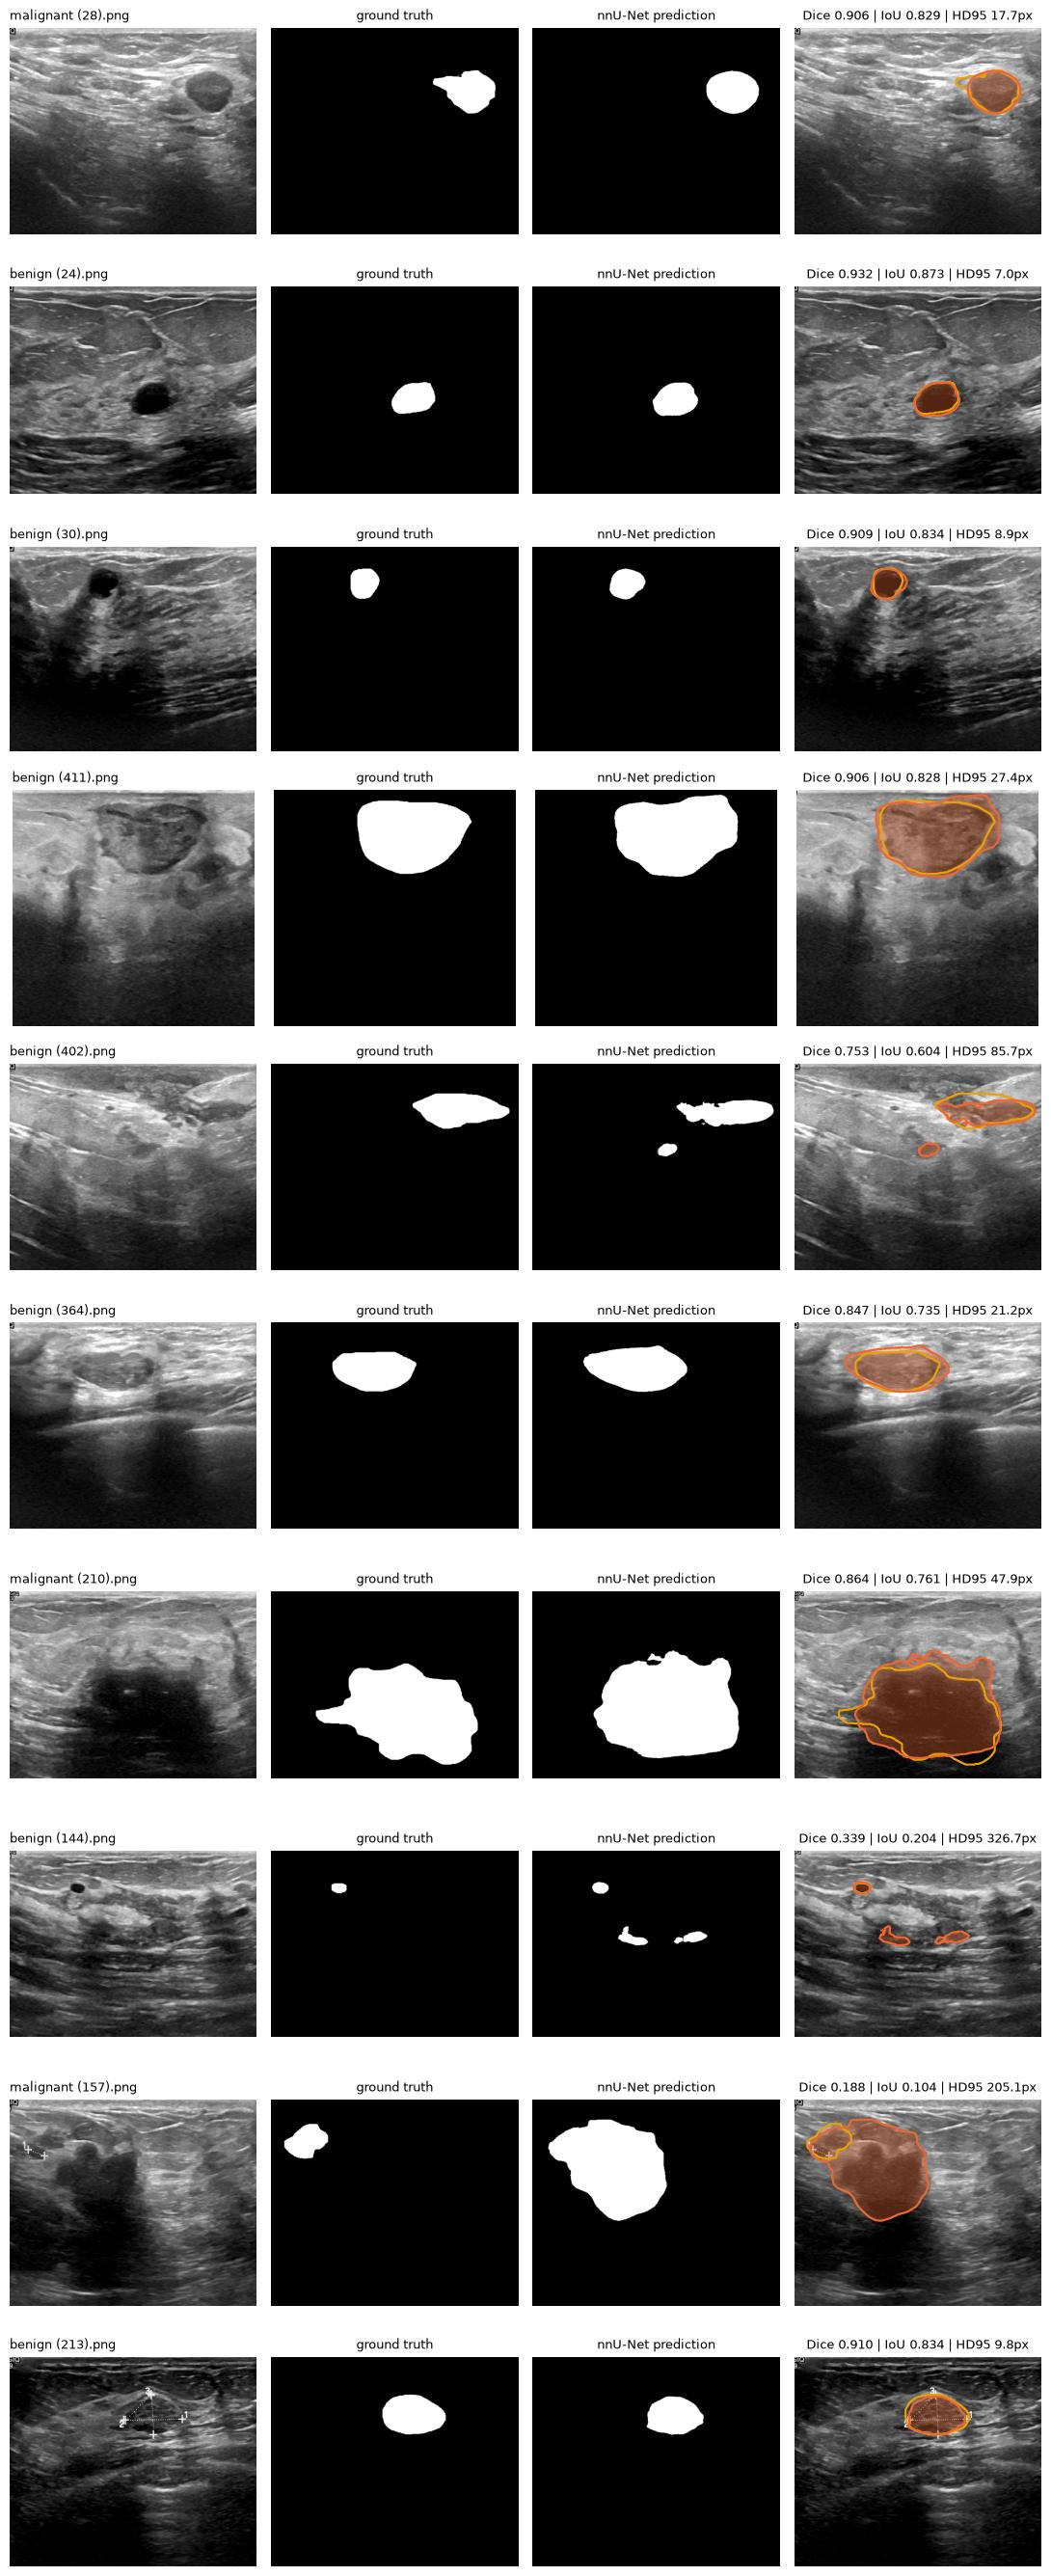

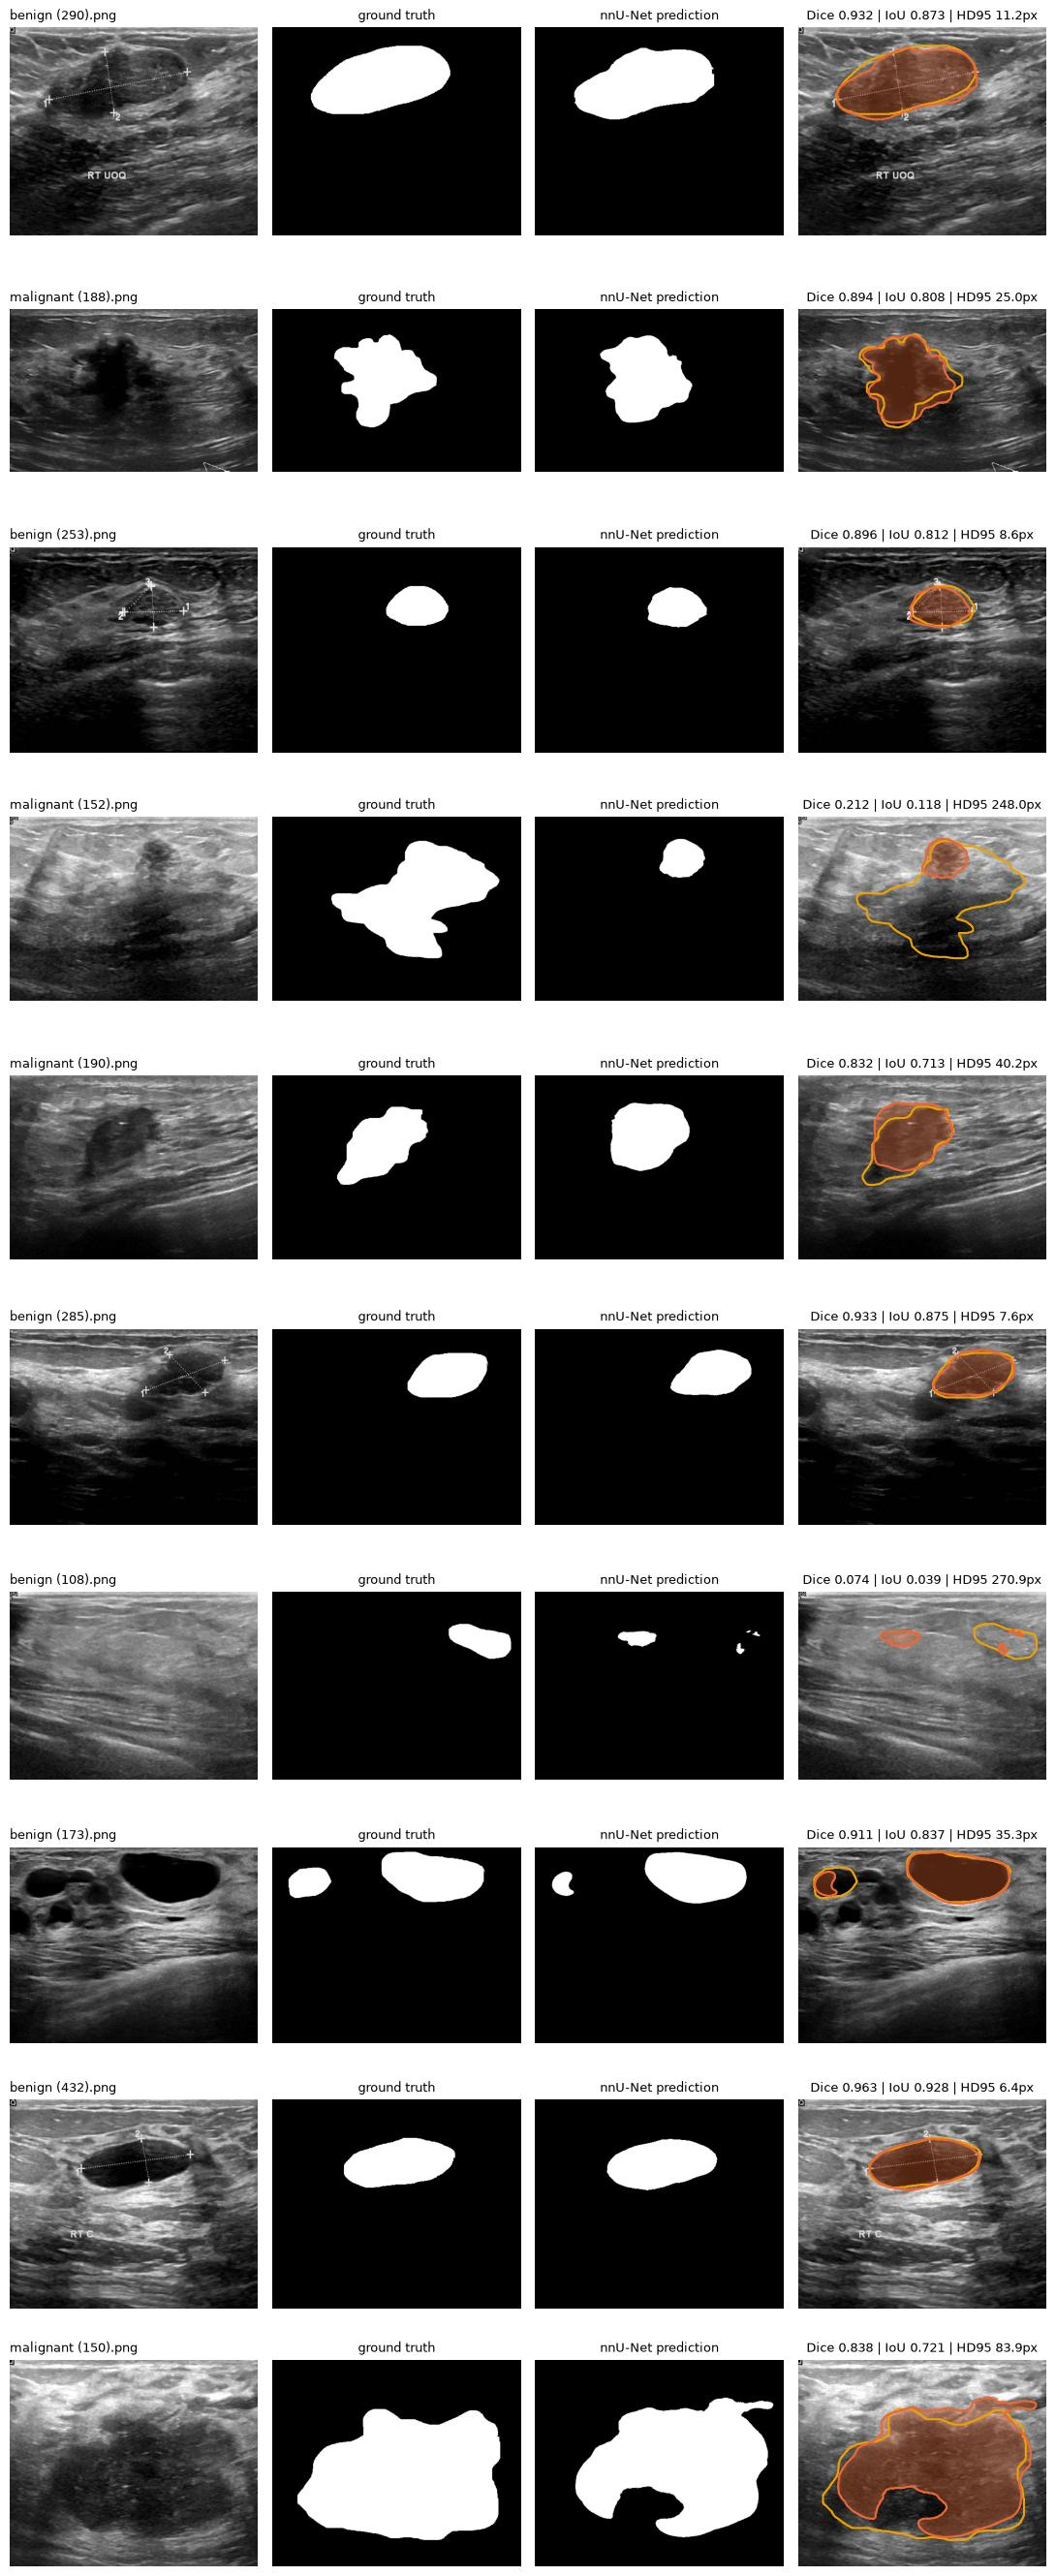

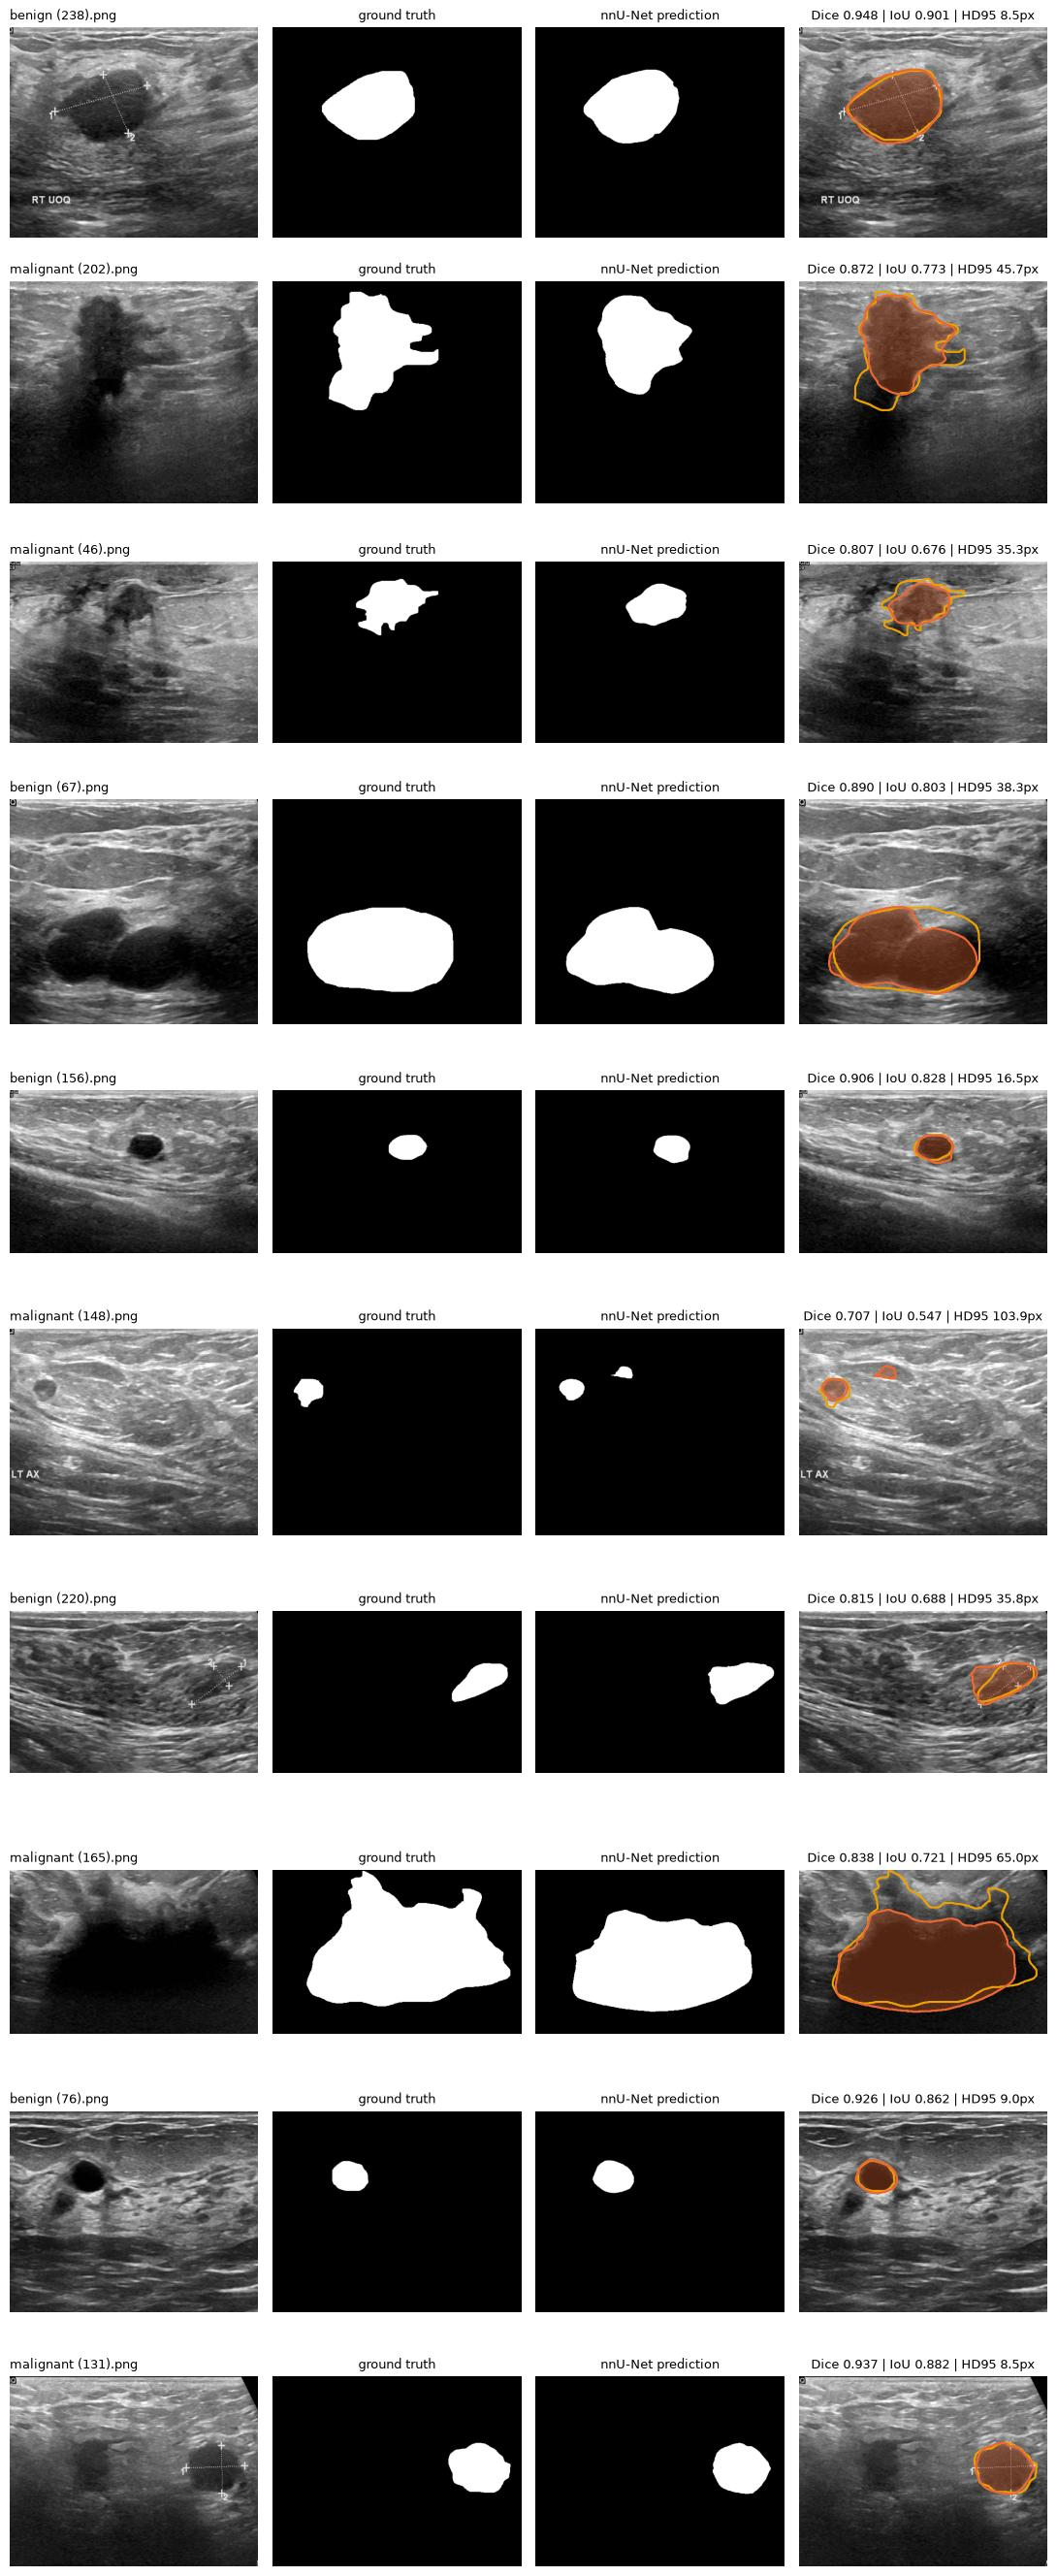

In [13]:
from matplotlib_inline.backend_inline import set_matplotlib_formats

GT_COLOR = "#eda100"   # ground-truth contour colour, the same in every notebook
# 130 rows of photos: embed as JPEG instead of PNG to keep the executed notebook small
set_matplotlib_formats("jpeg")


def show_page(names):
    fig, axes = plt.subplots(len(names), 4, figsize=(11, 2.7 * len(names)))
    axes = np.atleast_2d(axes)
    for r, name in enumerate(names):
        img, gt, pred = load_image(name), load_mask(name), pred_masks[name]
        row = metrics_df.set_index("image_name").loc[name]
        axes[r, 0].imshow(img, cmap="gray")
        axes[r, 0].set_title(f"{name}", fontsize=9, loc="left")
        axes[r, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[r, 1].set_title("ground truth", fontsize=9)
        axes[r, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[r, 2].set_title(f"{MODEL_LABEL} prediction", fontsize=9)
        axes[r, 3].imshow(img, cmap="gray")
        axes[r, 3].imshow(np.ma.masked_where(pred == 0, pred), cmap=ListedColormap([MODEL_COLOR]),
                          alpha=0.35, vmin=0, vmax=1)
        axes[r, 3].contour(gt, levels=[0.5], colors=GT_COLOR, linewidths=1.5)
        if pred.any():
            axes[r, 3].contour(pred, levels=[0.5], colors=MODEL_COLOR, linewidths=1.5)
        axes[r, 3].set_title(f"Dice {row.dice:.3f} | IoU {row.iou:.3f} | HD95 {row.hd95:.1f}px",
                             fontsize=9)
        for ax in axes[r]:
            ax.axis("off")
    fig.tight_layout()
    plt.show()


for start in range(0, len(test_names), 10):
    show_page(test_names[start:start + 10])